### Install Dependencies

In [ ]:
import warnings
warnings.filterwarnings('ignore')
def fxn():
    warnings.warn("deprecated", DeprecationWarning)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fxn()
%matplotlib inline
warnings.filterwarnings('ignore')


In [ ]:
!pip install --upgrade --force-reinstall "numpy<2" "scipy<1.15"

In [ ]:
!pip install xgboost imblearn

In [ ]:
!pip install "s3fs" --upgrade --use-deprecated=legacy-resolver

In [ ]:
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

### Import Modules

In [ ]:
import pandas as pd
import numpy as np
import boto3
import io
import joblib
from sklearn.feature_selection import  SelectKBest, f_classif
import matplotlib.pyplot as plt 
import seaborn as sns
from imblearn import under_sampling,over_sampling
from imblearn.over_sampling import SMOTE
from scipy.stats import zscore
from sklearn.preprocessing  import power_transform, StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.linear_model import LogisticRegression, SGDRegressor,Ridge, Lasso
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score,classification_report, confusion_matrix, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import KFold
import pickle
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder
from mlflow.tracking import MlflowClient
import mlflow, urllib3
import subprocess
import os
from io import BytesIO



In [ ]:
%matplotlib inline

### Load Data and Analyse Data

In [ ]:
def get_s3_client(endpoint_host: str, ssl_enabled: bool):
    """Return boto3 client configured with dynamic JWT auth."""
    endpoint_url = f"http{'s' if ssl_enabled else ''}://{endpoint_host}"
    jwt_token = os.environ["AUTH_TOKEN"]
    s3 = boto3.client(
        "s3",
        aws_access_key_id=jwt_token,
        aws_secret_access_key="s3",  # dummy, just required for boto3
        endpoint_url=endpoint_url,
        use_ssl=ssl_enabled,
    )
    return s3

def read_csvs_from_s3(bucket: str, prefix: str, endpoint_host: str, ssl_enabled: bool) -> pd.DataFrame:
    """Read all CSV files under a given prefix from S3 and return one merged DataFrame."""
    s3 = get_s3_client(endpoint_host, ssl_enabled)

    # List all objects under the prefix
    response = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)
    if "Contents" not in response:
        raise FileNotFoundError(f"No files found at s3://{bucket}/{prefix}")

    # Collect CSVs into a list of DataFrames
    dfs = []
    for obj in response["Contents"]:
        key = obj["Key"]
        if key.endswith(".csv"):
            file_obj = s3.get_object(Bucket=bucket, Key=key)
            df = pd.read_csv(BytesIO(file_obj["Body"].read()))
            dfs.append(df)

    if not dfs:
        raise FileNotFoundError(f"No CSV files found at s3://{bucket}/{prefix}")

    # Merge into one final DataFrame
    return pd.concat(dfs, ignore_index=True)

In [ ]:
# Set up AWS credentials and create S3 client
config = {
    "KSERVE_MODEL_NAME": "bank-demo-10-171023",
    "SERVICE_ACCOUNT": "kserve-local-s3"
}

EXPERIMENT_NAME = config["KSERVE_MODEL_NAME"]
mlflow.set_experiment(EXPERIMENT_NAME)
EXPERIMENT_ID = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
#need to read from secret 
df = read_csvs_from_s3(
    bucket="bank",
    prefix="bank/merged_data/",
    endpoint_host="minio-service.ezdata-system.svc.cluster.local:30000",
    ssl_enabled=False
)
#df = pd.read_csv("/mnt/shared/spark/bank/part-00000-280f56f2-3ea0-4e2e-b86d-eb9283702782-c000.csv")
df
df.head(25)
df.size
df.dtypes
df.shape
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5061 entries, 0 to 5060
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        5061 non-null   int64 
 1   job        5061 non-null   object
 2   marital    5061 non-null   object
 3   education  5061 non-null   object
 4   default1   5061 non-null   object
 5   balance    5061 non-null   int64 
 6   housing    5061 non-null   object
 7   loan       5061 non-null   object
 8   contact    5061 non-null   object
 9   day        5061 non-null   int64 
 10  month      5061 non-null   object
 11  duration   5061 non-null   int64 
 12  campaign   5061 non-null   int64 
 13  pdays      5061 non-null   int64 
 14  previous   5061 non-null   int64 
 15  poutcome   5061 non-null   object
 16  target     5061 non-null   object
dtypes: int64(7), object(10)
memory usage: 672.3+ KB


Index(['age', 'job', 'marital', 'education', 'default1', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'target'],
      dtype='object')

<Axes: >

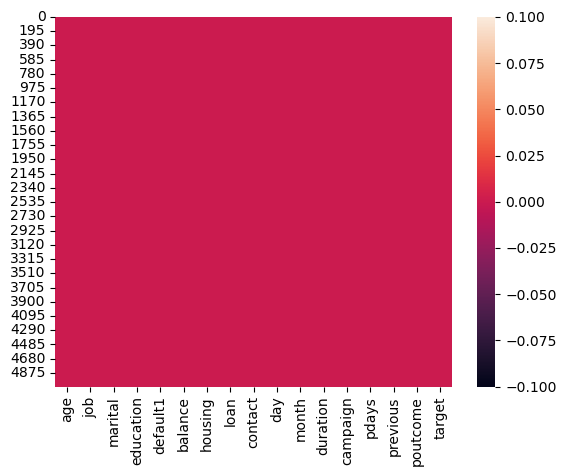

In [ ]:
#checking Null Values in the dataset
df.isnull()

#checking the sum of the Dataset
df.isnull().sum()

#checking Null values by heatmap
sns.heatmap(df.isnull())

In [ ]:
#checking any space in the dataset 

(df == ' ?')
(df == ' ?').sum()
#Or
(df == ' ').sum()
#checking any null value in the target column
df[df['target'] == '']
df[df['target'] == ''].index
df['target'].value_counts()
df['target'].unique()
df.nunique()

age            68
job            13
marital         3
education       4
default1        2
balance      2832
housing         2
loan            2
contact         3
day            31
month          12
duration     1272
campaign       50
pdays         542
previous       25
poutcome        4
target          2
dtype: int64

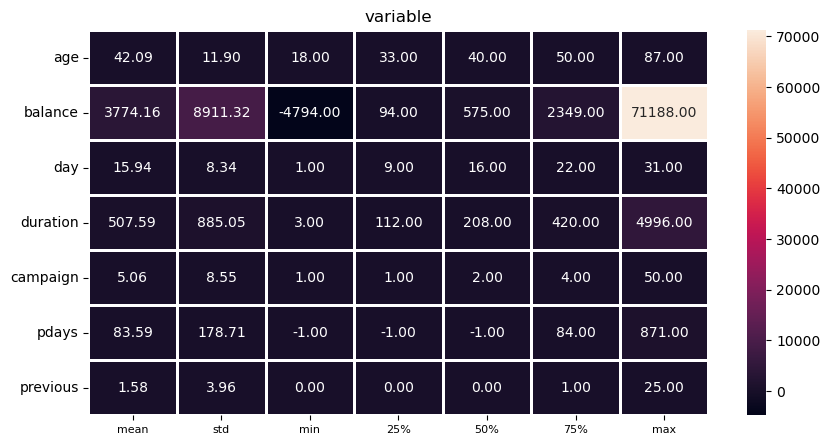

In [ ]:
df.describe()
plt.figure(figsize=(10,5))
sns.heatmap(round(df.describe()[1:].transpose(),2),linewidth=2,annot=True,fmt='.2f')
plt.xticks(fontsize=14)
plt.xticks(fontsize=8)
plt.title('variable')
plt.show()

target
no     4253
yes     808
Name: count, dtype: int64


<Axes: xlabel='target', ylabel='Count'>

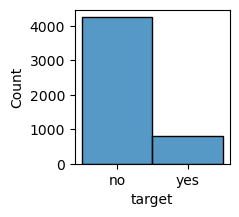

In [ ]:
# Data Cleaning and Preprocessing
df['age'].value_counts()
df['age'].unique()
#Histplot for "tenure" column
print(df["target"].value_counts())
plt.figure(figsize=(2,2))
sns.histplot(x='target',data=df,bins=73)

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

<Axes: xlabel='target', ylabel='count'>

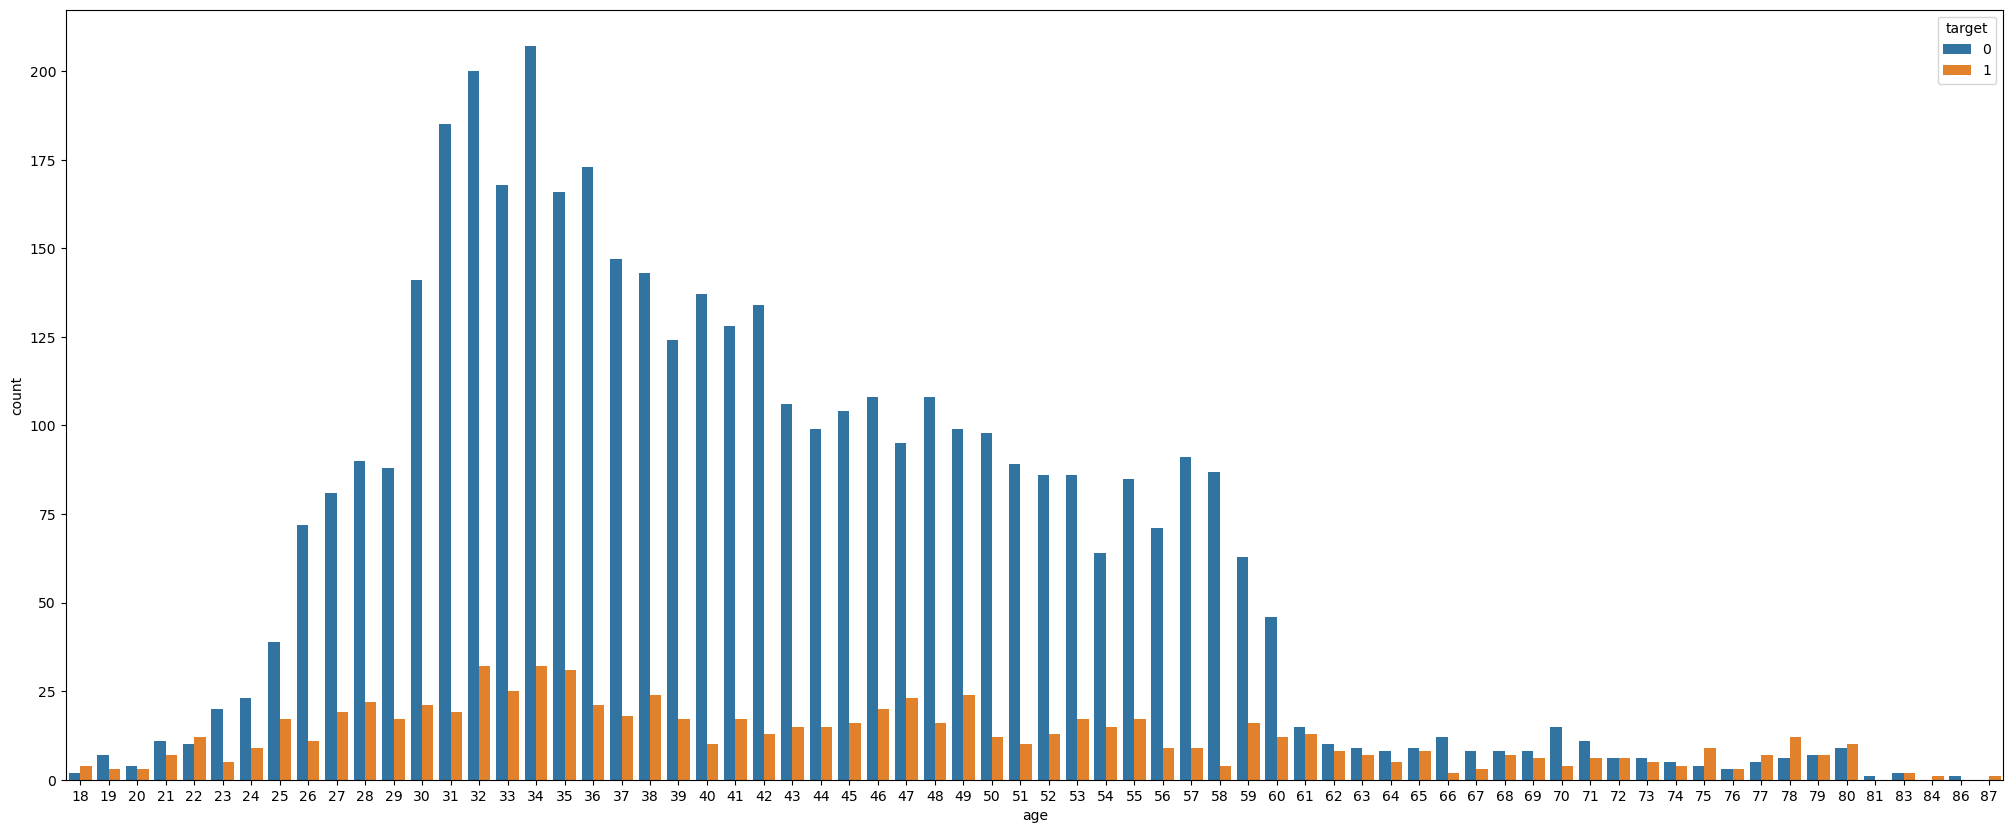

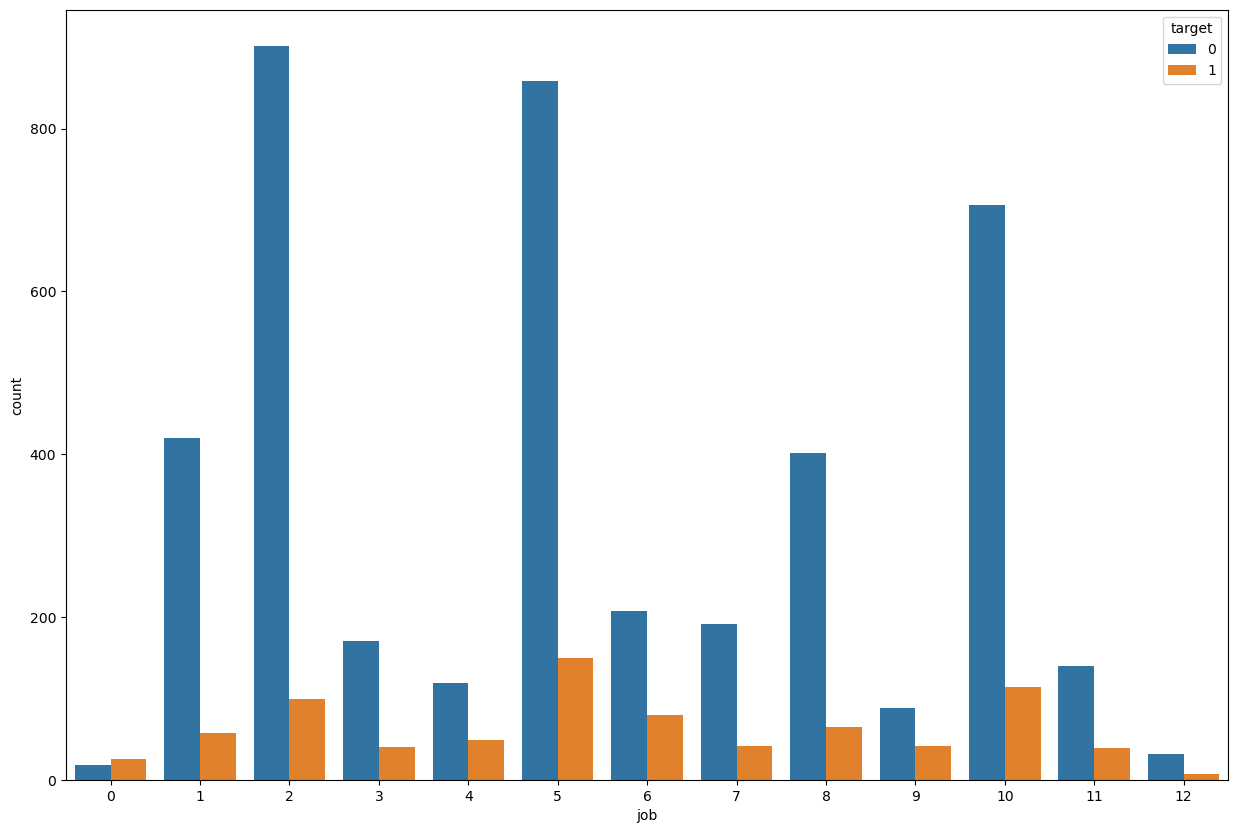

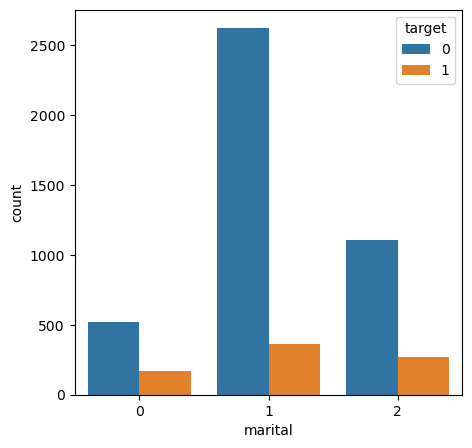

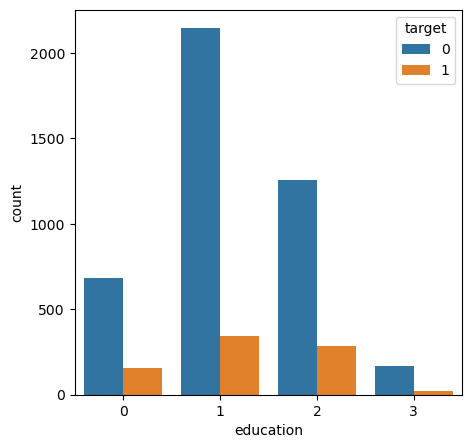

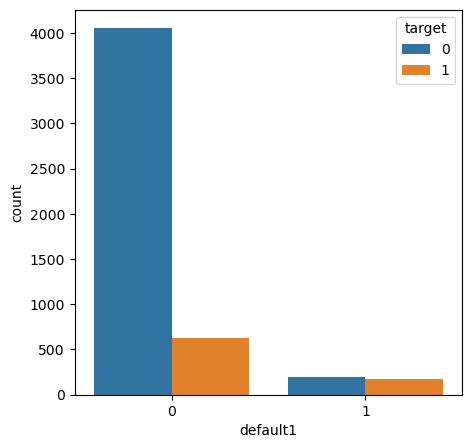

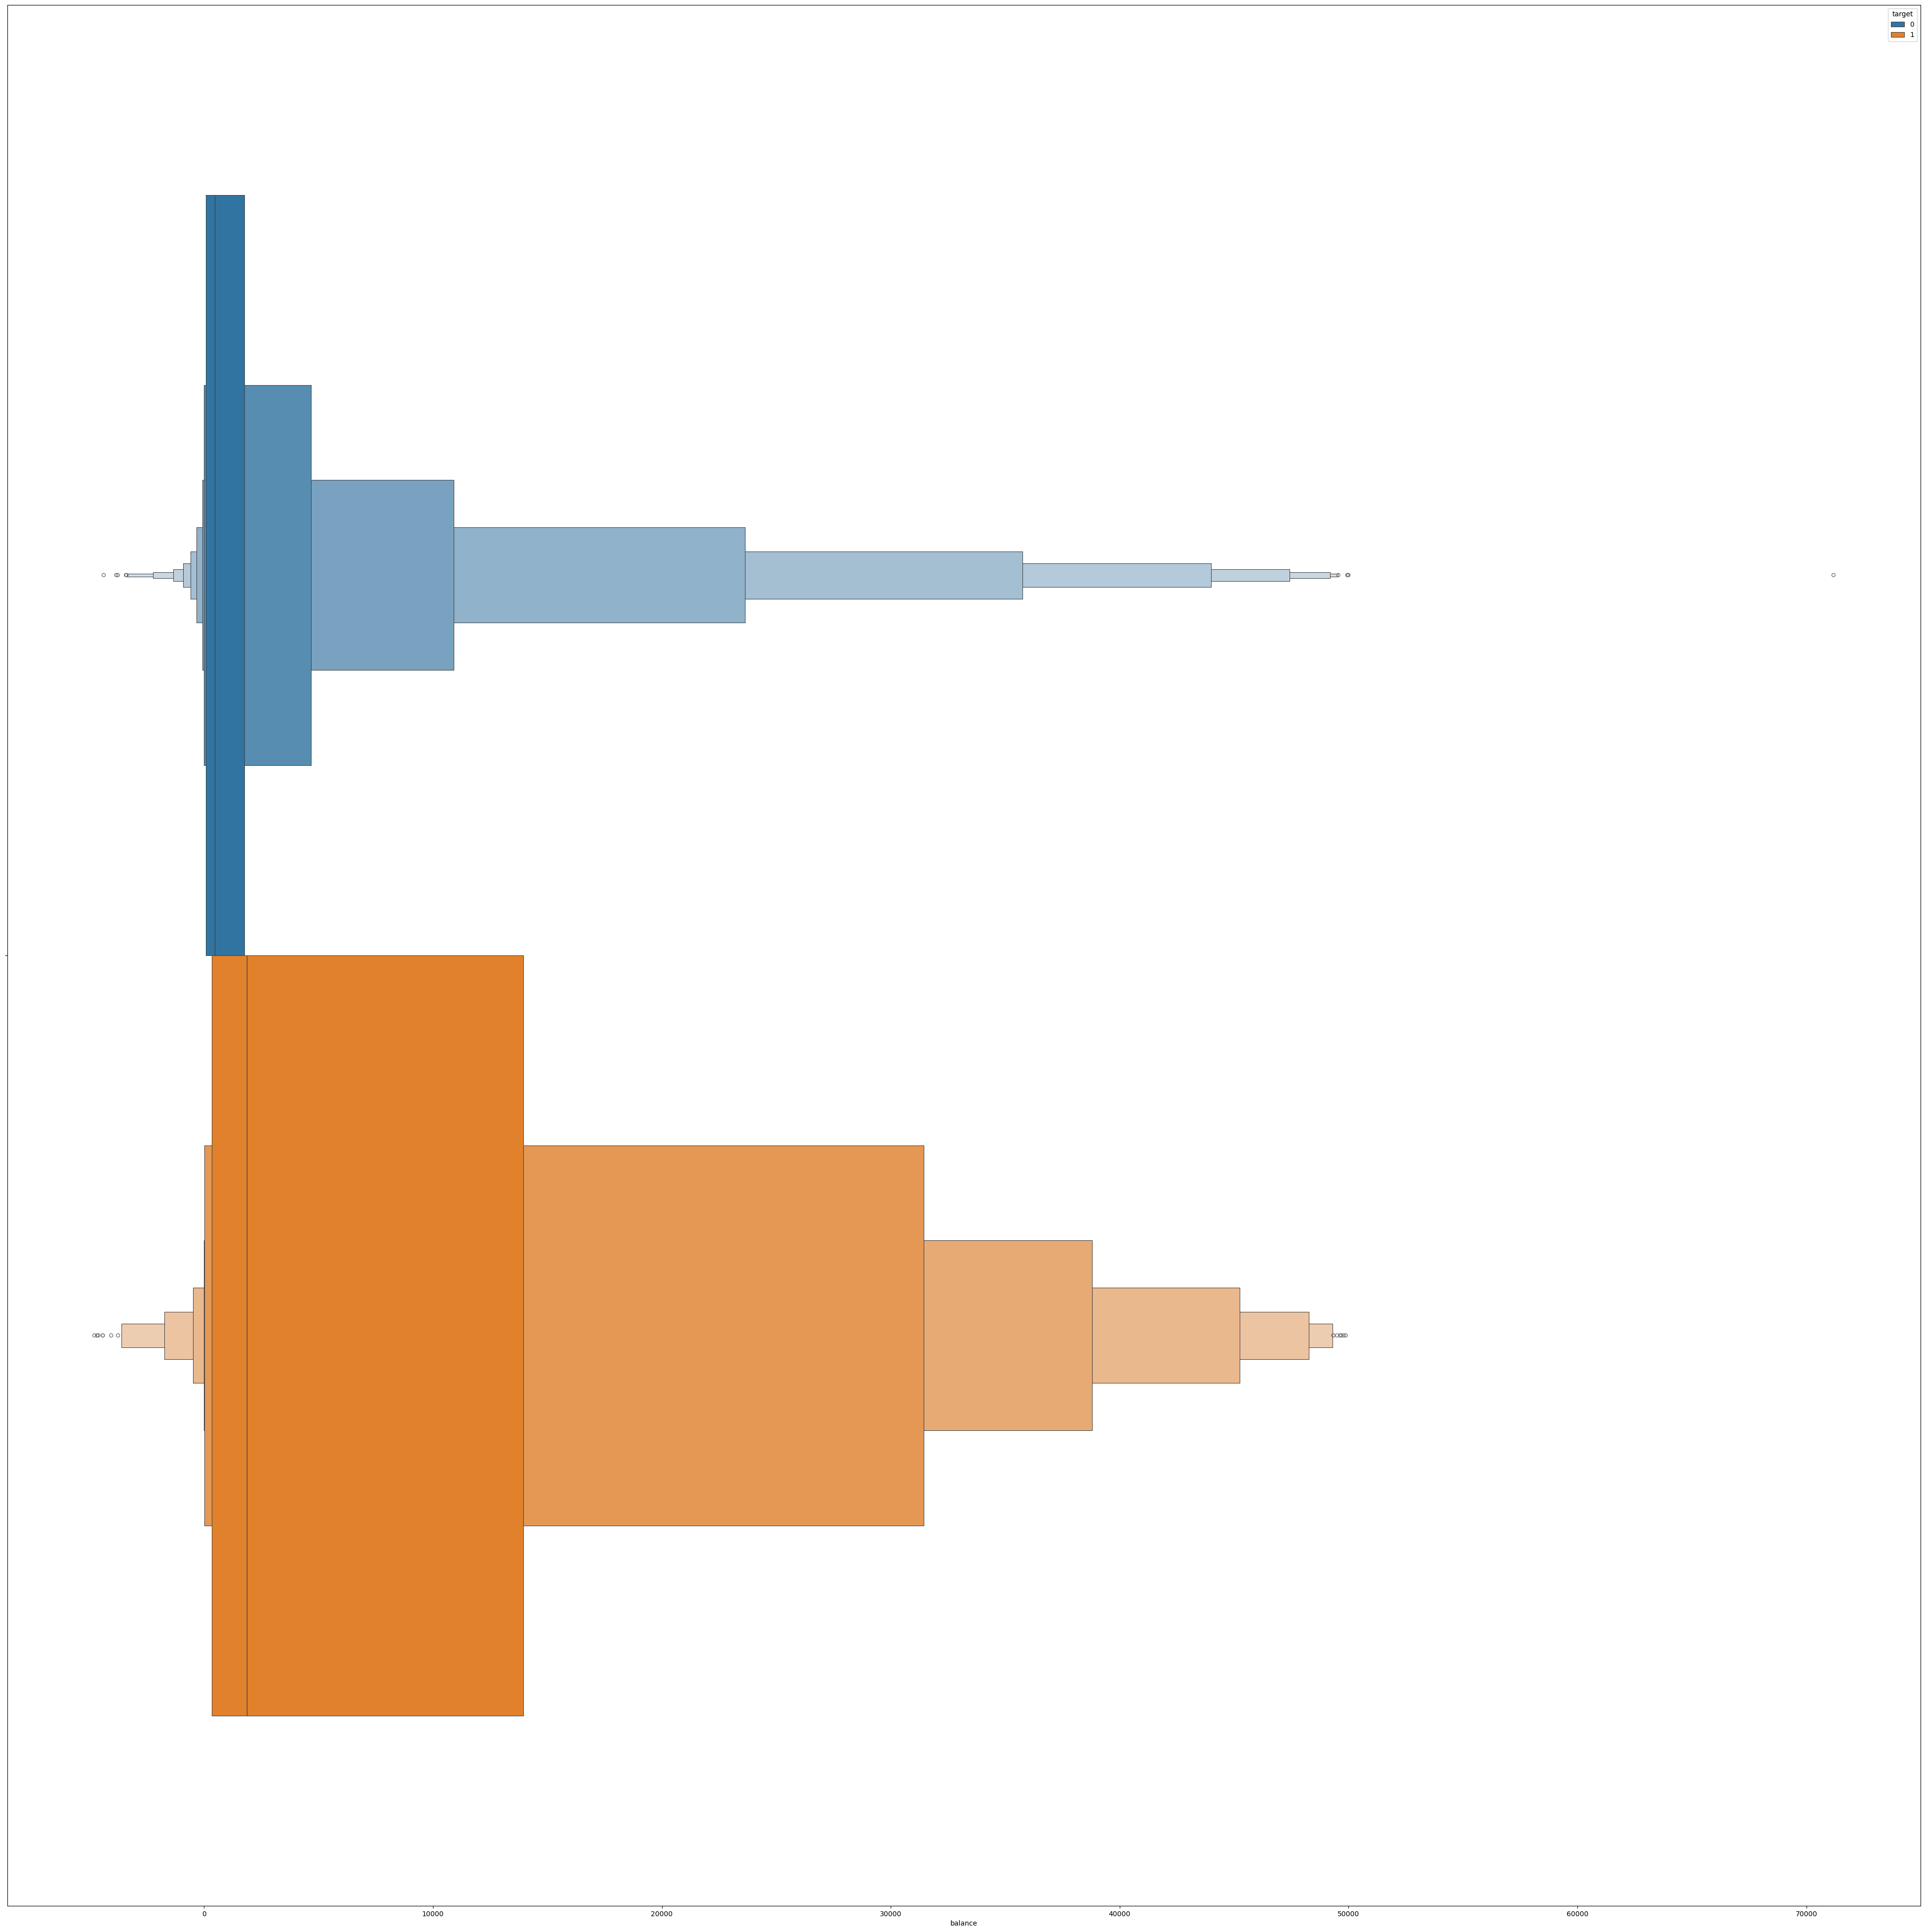

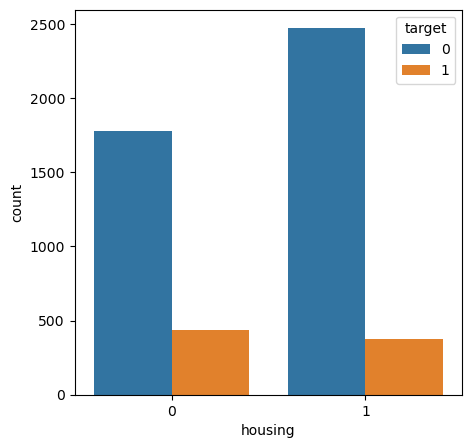

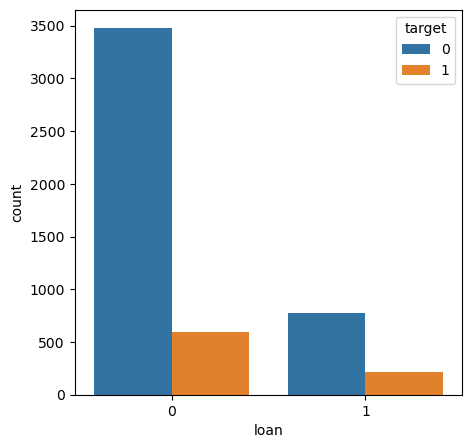

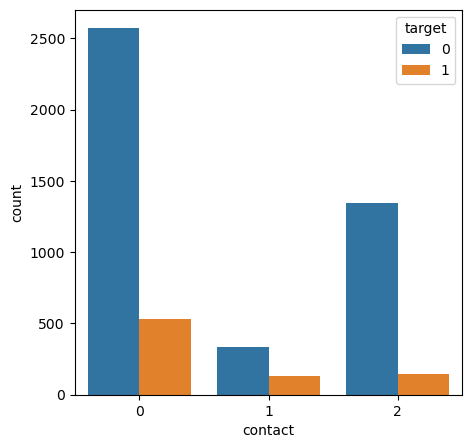

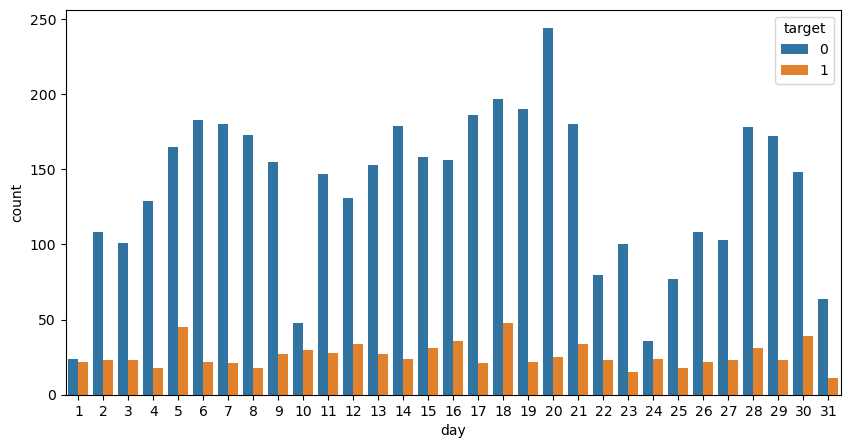

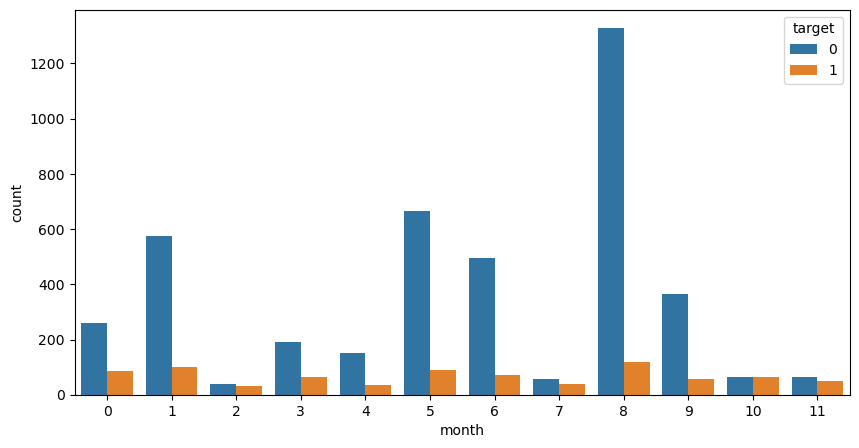

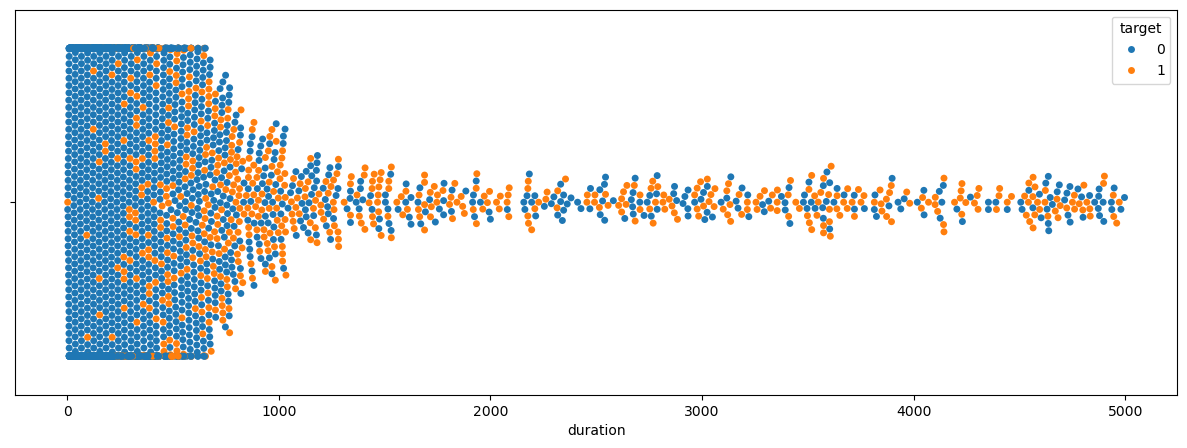

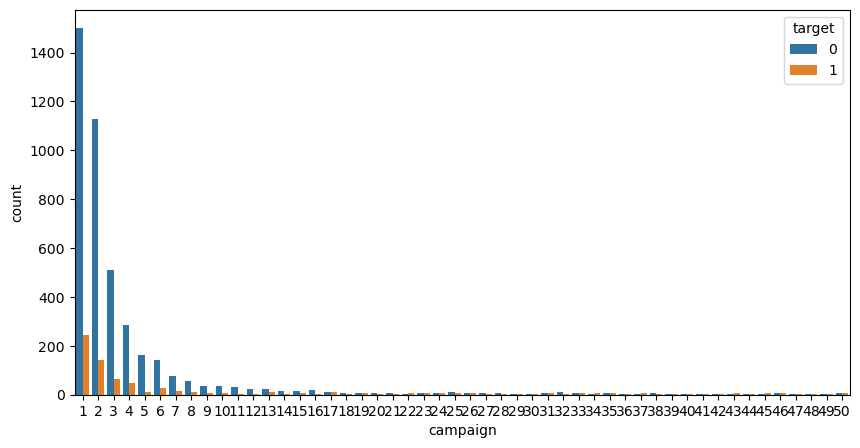

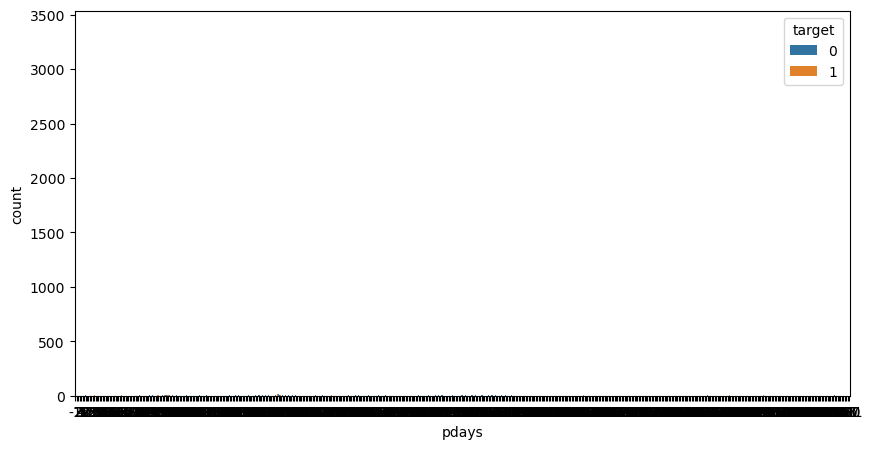

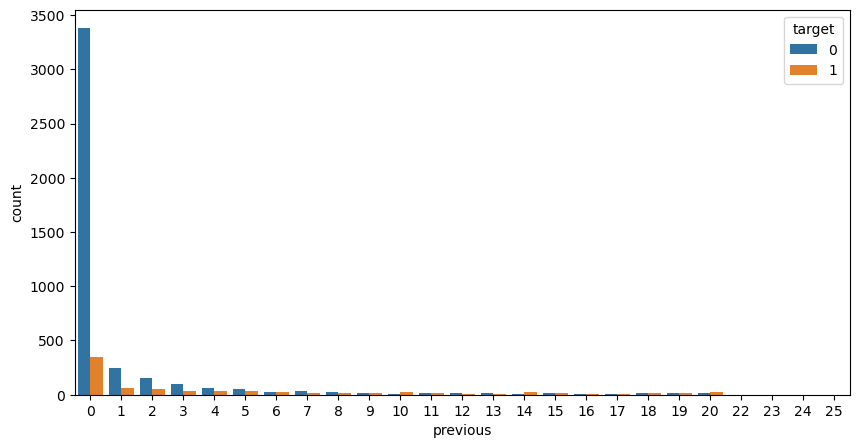

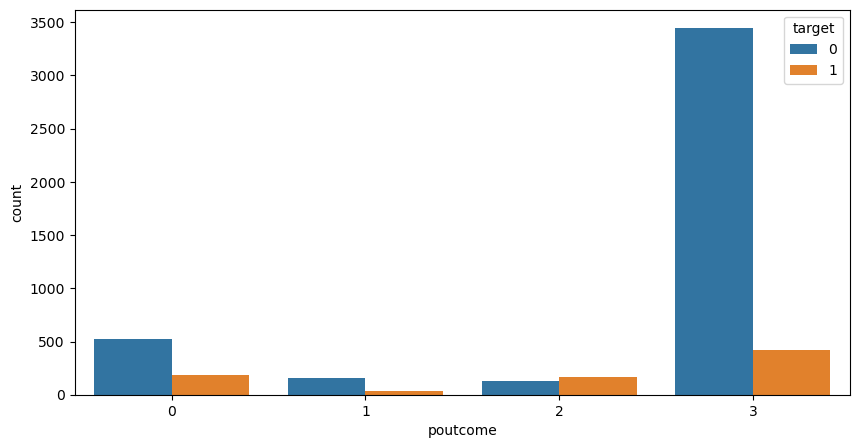

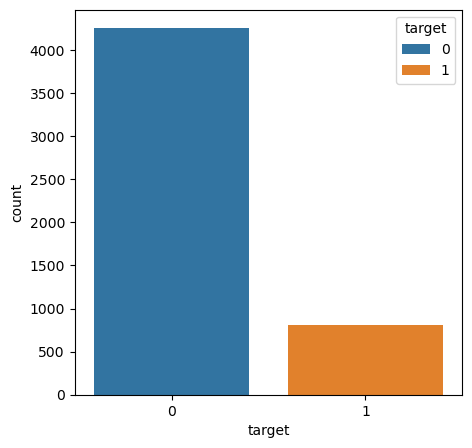

In [ ]:
#  Bivariate Analysis
plt.figure(figsize=(25,10))
sns.countplot(x='age', data=df, hue='target')

plt.figure(figsize=(15,10))
sns.countplot(x='job', data=df,hue='target')

plt.figure(figsize=(5,5))
sns.countplot(x='marital', data=df,hue='target')

plt.figure(figsize=(5,5))
sns.countplot(x='education', data=df,hue='target')

plt.figure(figsize=(5,5))
sns.countplot(x='default1', data=df,hue='target')

plt.figure(figsize=(50,50))
sns.boxenplot(x='balance', data=df,hue='target')

plt.figure(figsize=(5,5))
sns.countplot(x='housing', data=df,hue='target')

plt.figure(figsize=(5,5))
sns.countplot(x='loan', data=df,hue='target')

plt.figure(figsize=(5,5))
sns.countplot(x='contact', data=df,hue='target')

plt.figure(figsize=(10,5))
sns.countplot(x='day', data=df,hue='target')

plt.figure(figsize=(10,5))
sns.countplot(x='month', data=df,hue='target')

plt.figure(figsize=(15,5))
sns.swarmplot(x='duration', data=df,hue='target')

plt.figure(figsize=(10,5))
sns.countplot(x='campaign', data=df,hue='target')

plt.figure(figsize=(10,5))
sns.countplot(x='pdays', data=df,hue='target')

plt.figure(figsize=(10,5))
sns.countplot(x='previous', data=df,hue='target')

plt.figure(figsize=(10,5))
sns.countplot(x='poutcome', data=df,hue='target')

plt.figure(figsize=(5,5))
sns.countplot(x='target', data=df,hue='target')

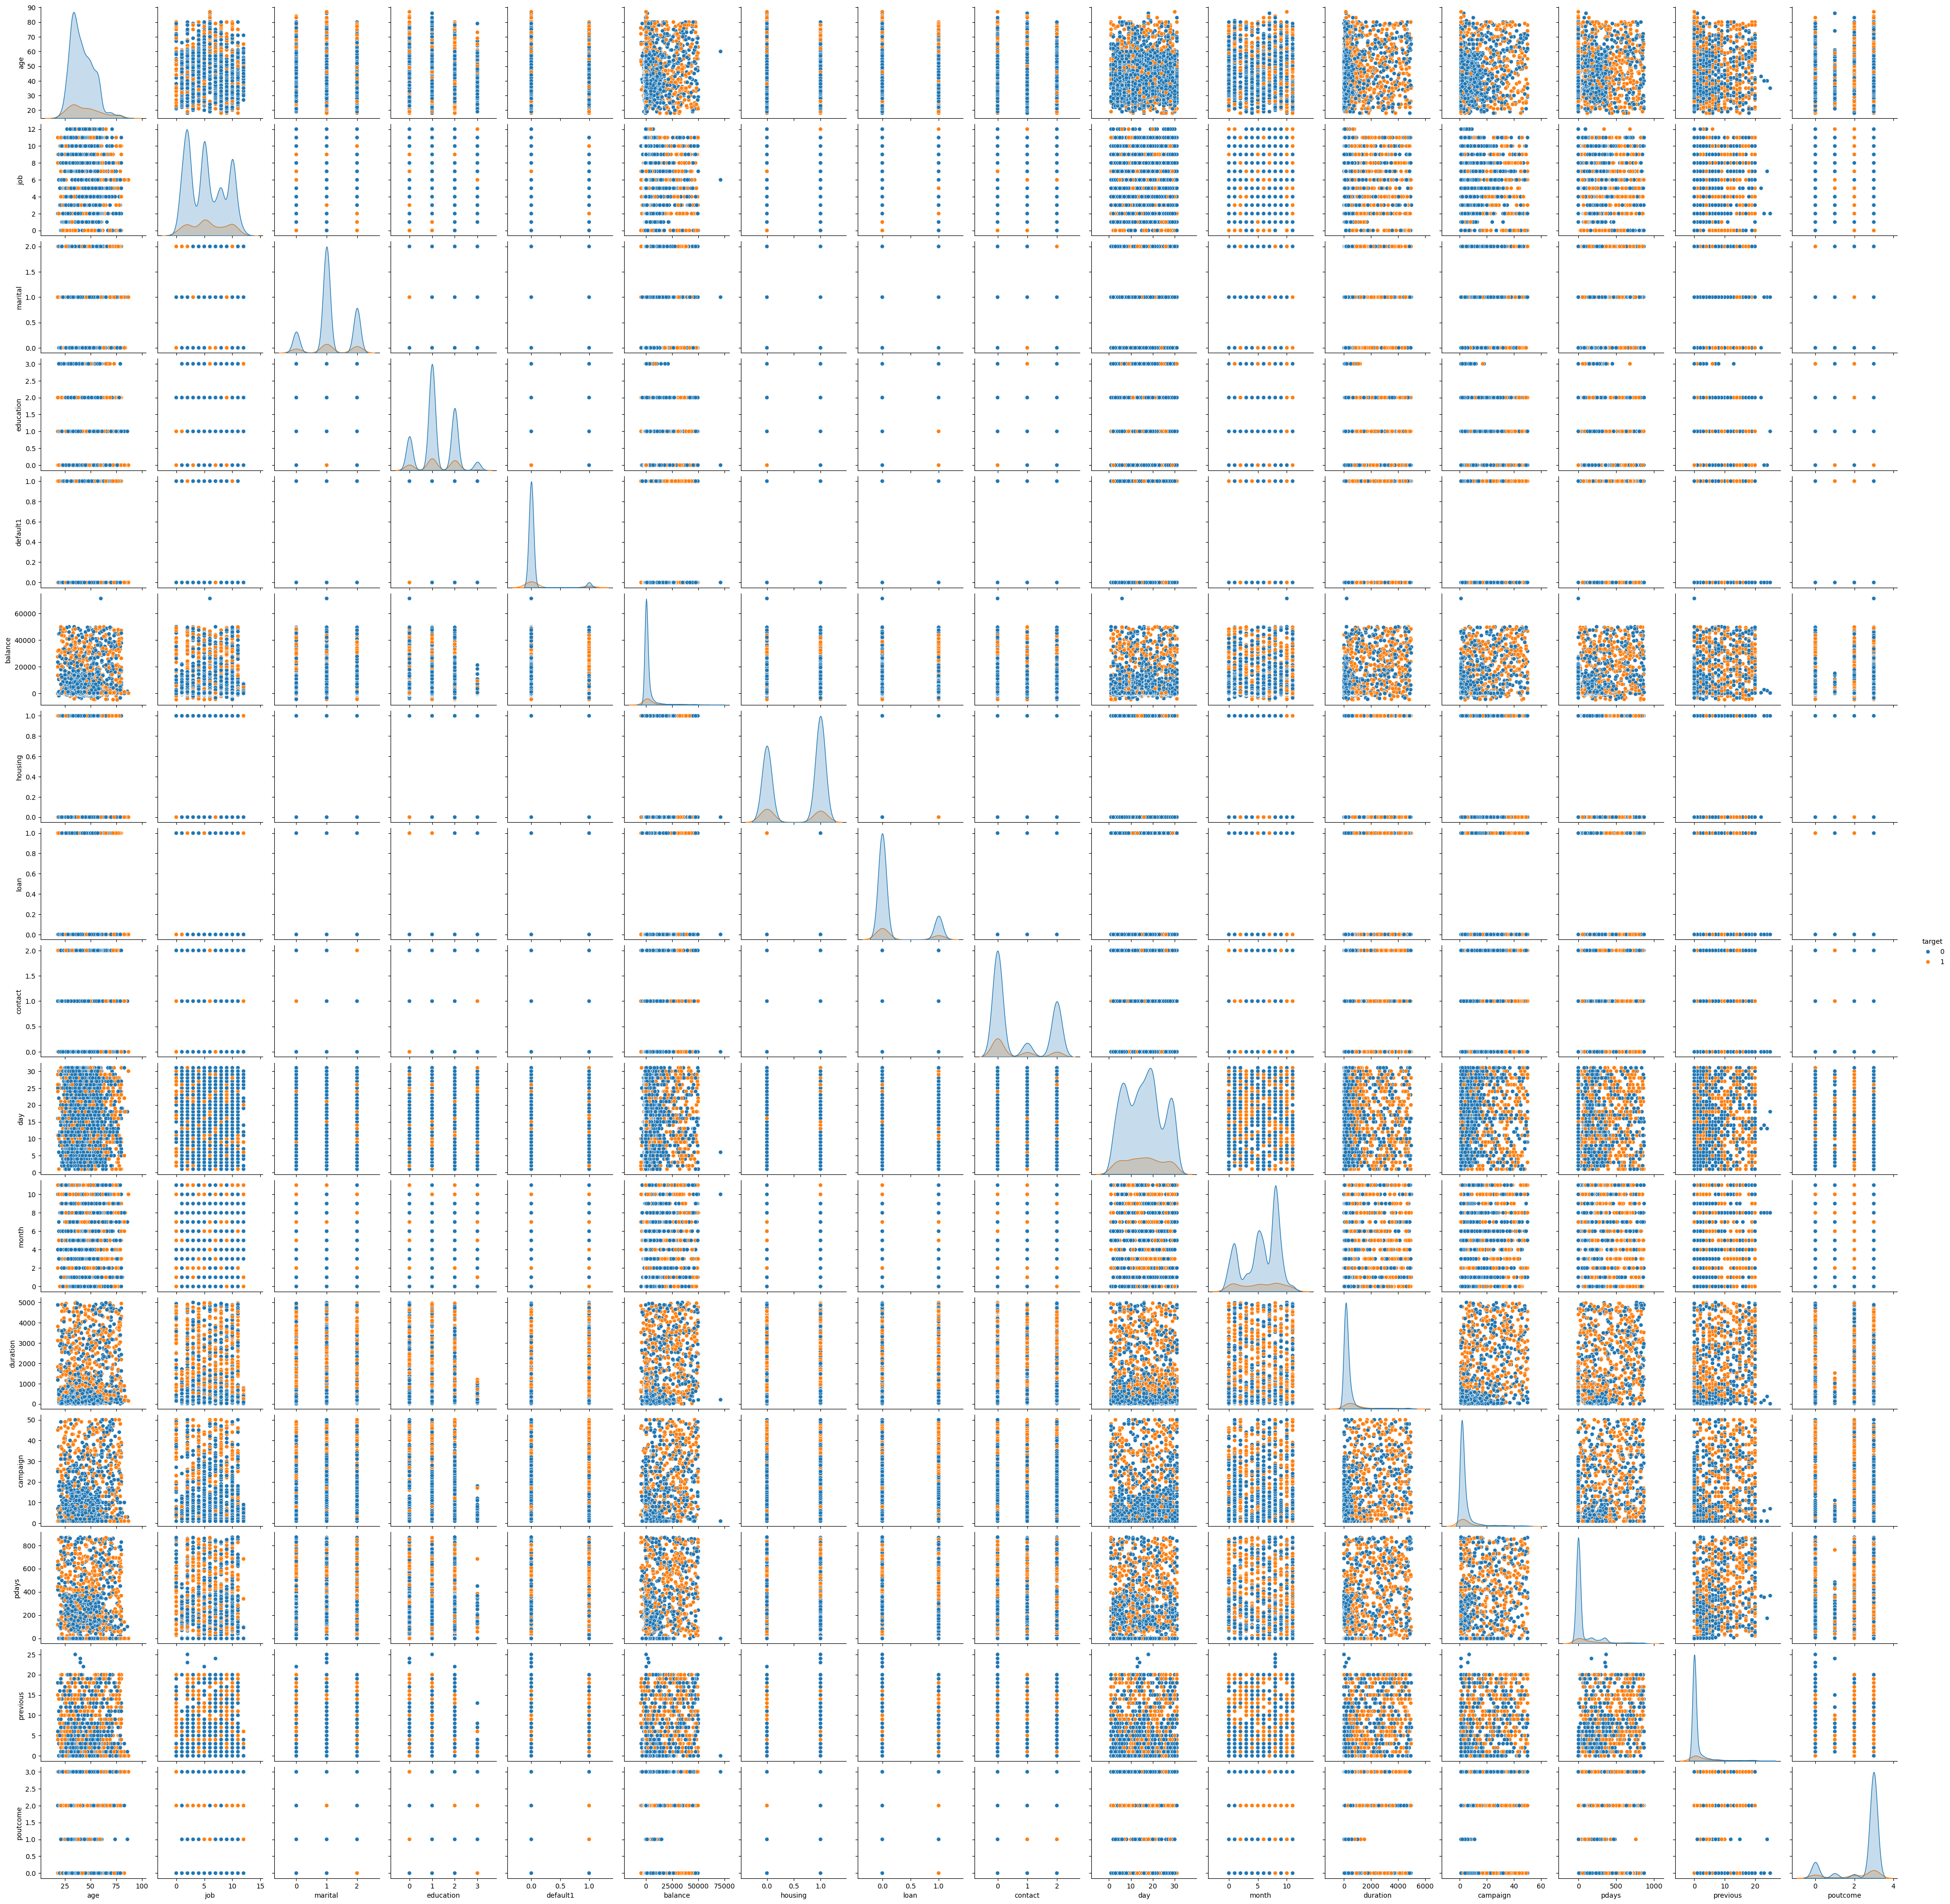

In [ ]:
sns.pairplot(df,hue='target')

In [ ]:
enc = LabelEncoder()
for i in df.columns:
    if df[i].dtypes =='object':
        df[i]=enc.fit_transform(df[i].values.reshape(-1,1))

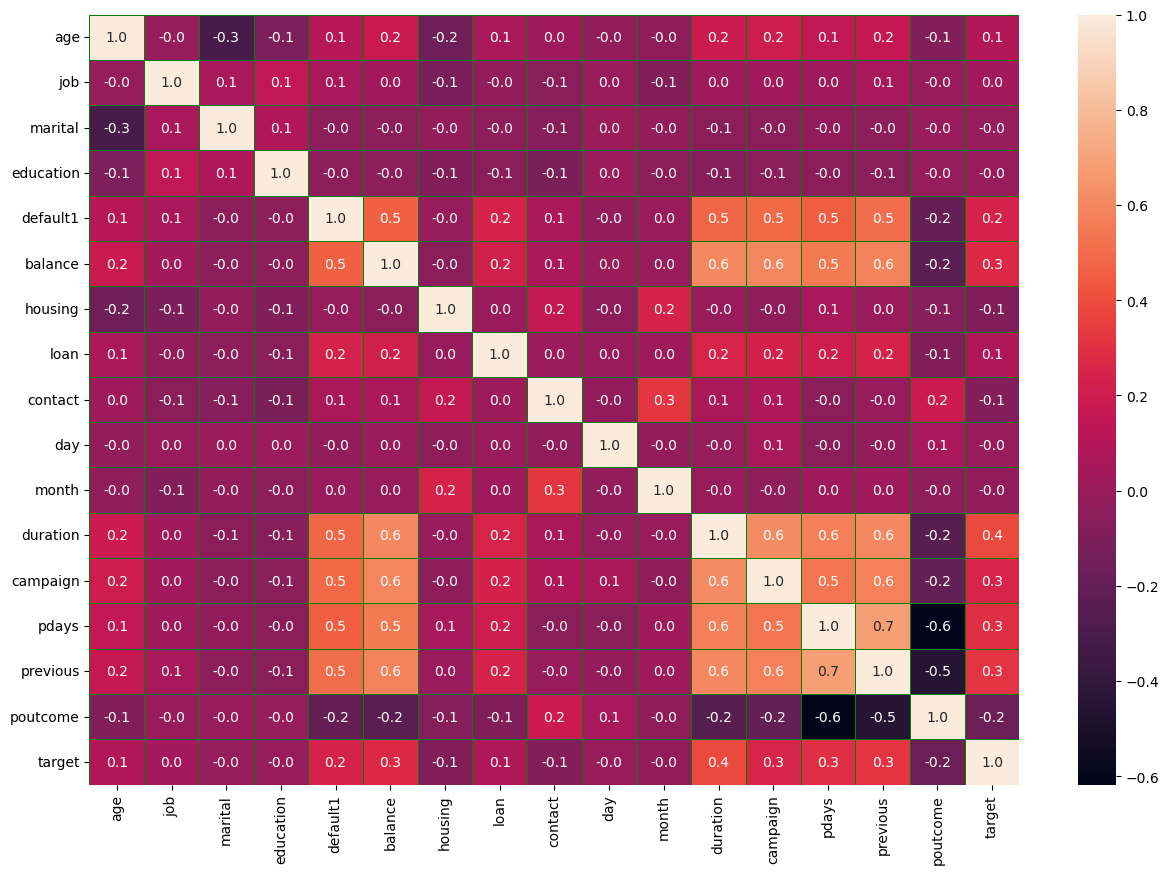

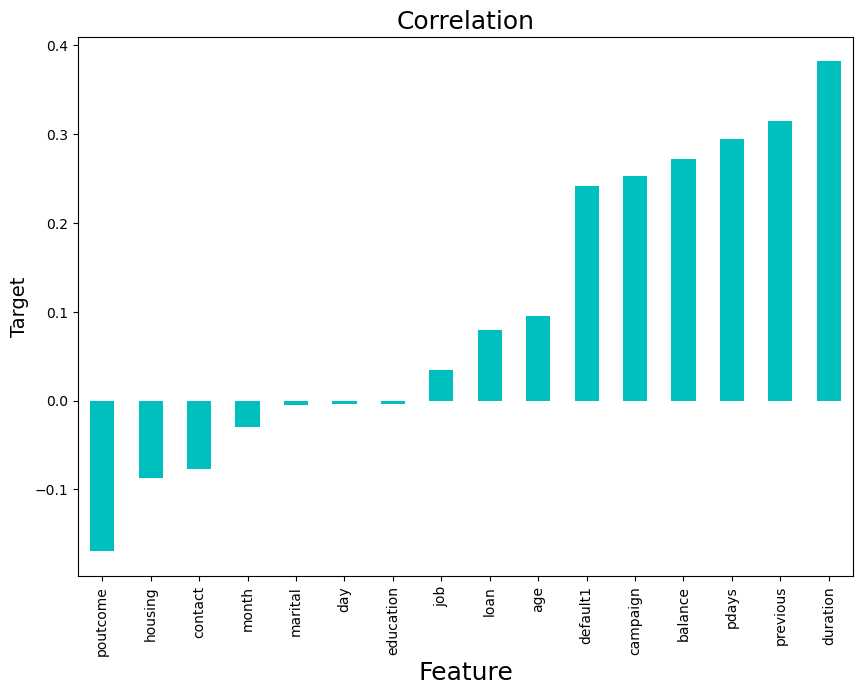

In [ ]:
#  Checking Correlation
df.head(50)
df.corr()
df.corr()['target'].sort_values()

# Checking Correlation with Heatmap

plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True, linewidths=0.5,linecolor='green',fmt='.1f')

#  Checking Correlation with barplot
plt.figure(figsize=(10,7))
df.corr()['target'].sort_values(ascending=True).drop(['target']).plot(kind='bar',color = 'c')
plt.xlabel('Feature',fontsize=18)
plt.ylabel('Target',fontsize=14)
plt.title('Correlation',fontsize = 18)
plt.show()

In [ ]:
# We can observe :
# All columns are sorted in ascending order showing least to strong correlation with target column. 
# 13 columns are negatively correlated and 7 columns are positively correlated. Column 'MonthlyCharges' 
# is highly correlated with Target column 'Churn' and Column 'Contract' is least correlated with Target column 'Churn'.

age          0.766592
job          0.201359
marital     -0.106270
education    0.135743
default1     3.236636
balance      3.356140
housing     -0.252203
loan         1.530413
contact      0.669907
day          0.082110
month       -0.421256
duration     3.262007
campaign     3.280323
pdays        2.445342
previous     3.112438
poutcome    -1.627539
target       1.858937
dtype: float64

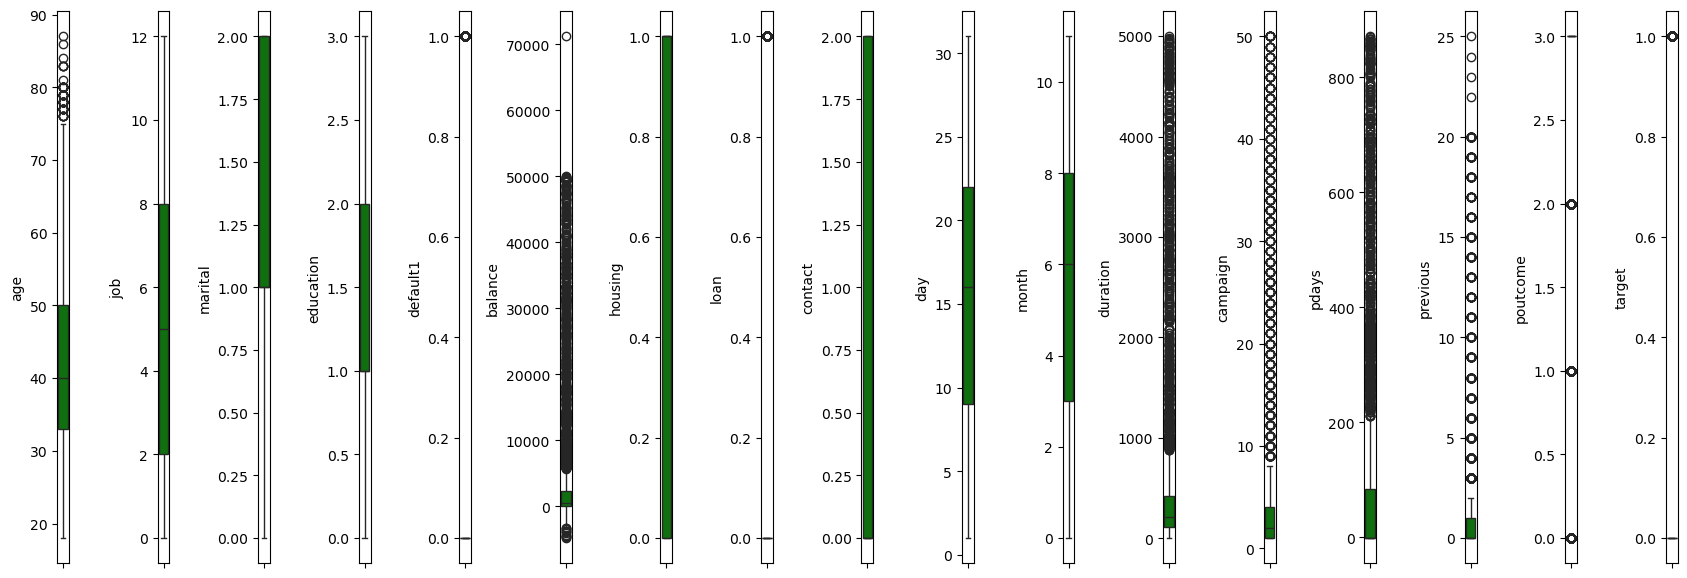

In [ ]:
# Checking Outliers
collist=df.columns.values
ncol=21
nrows=11
plt.figure(figsize=(ncol,3*ncol))
for column in range(0,len(collist)):
    plt.subplot(nrows,ncol,column+1)
    sns.boxplot(data=df[collist[column]],color='green',orient='v')
  #  plt.xlabel(column,frontsize = 15)
    plt.tight_layout()
df.skew()

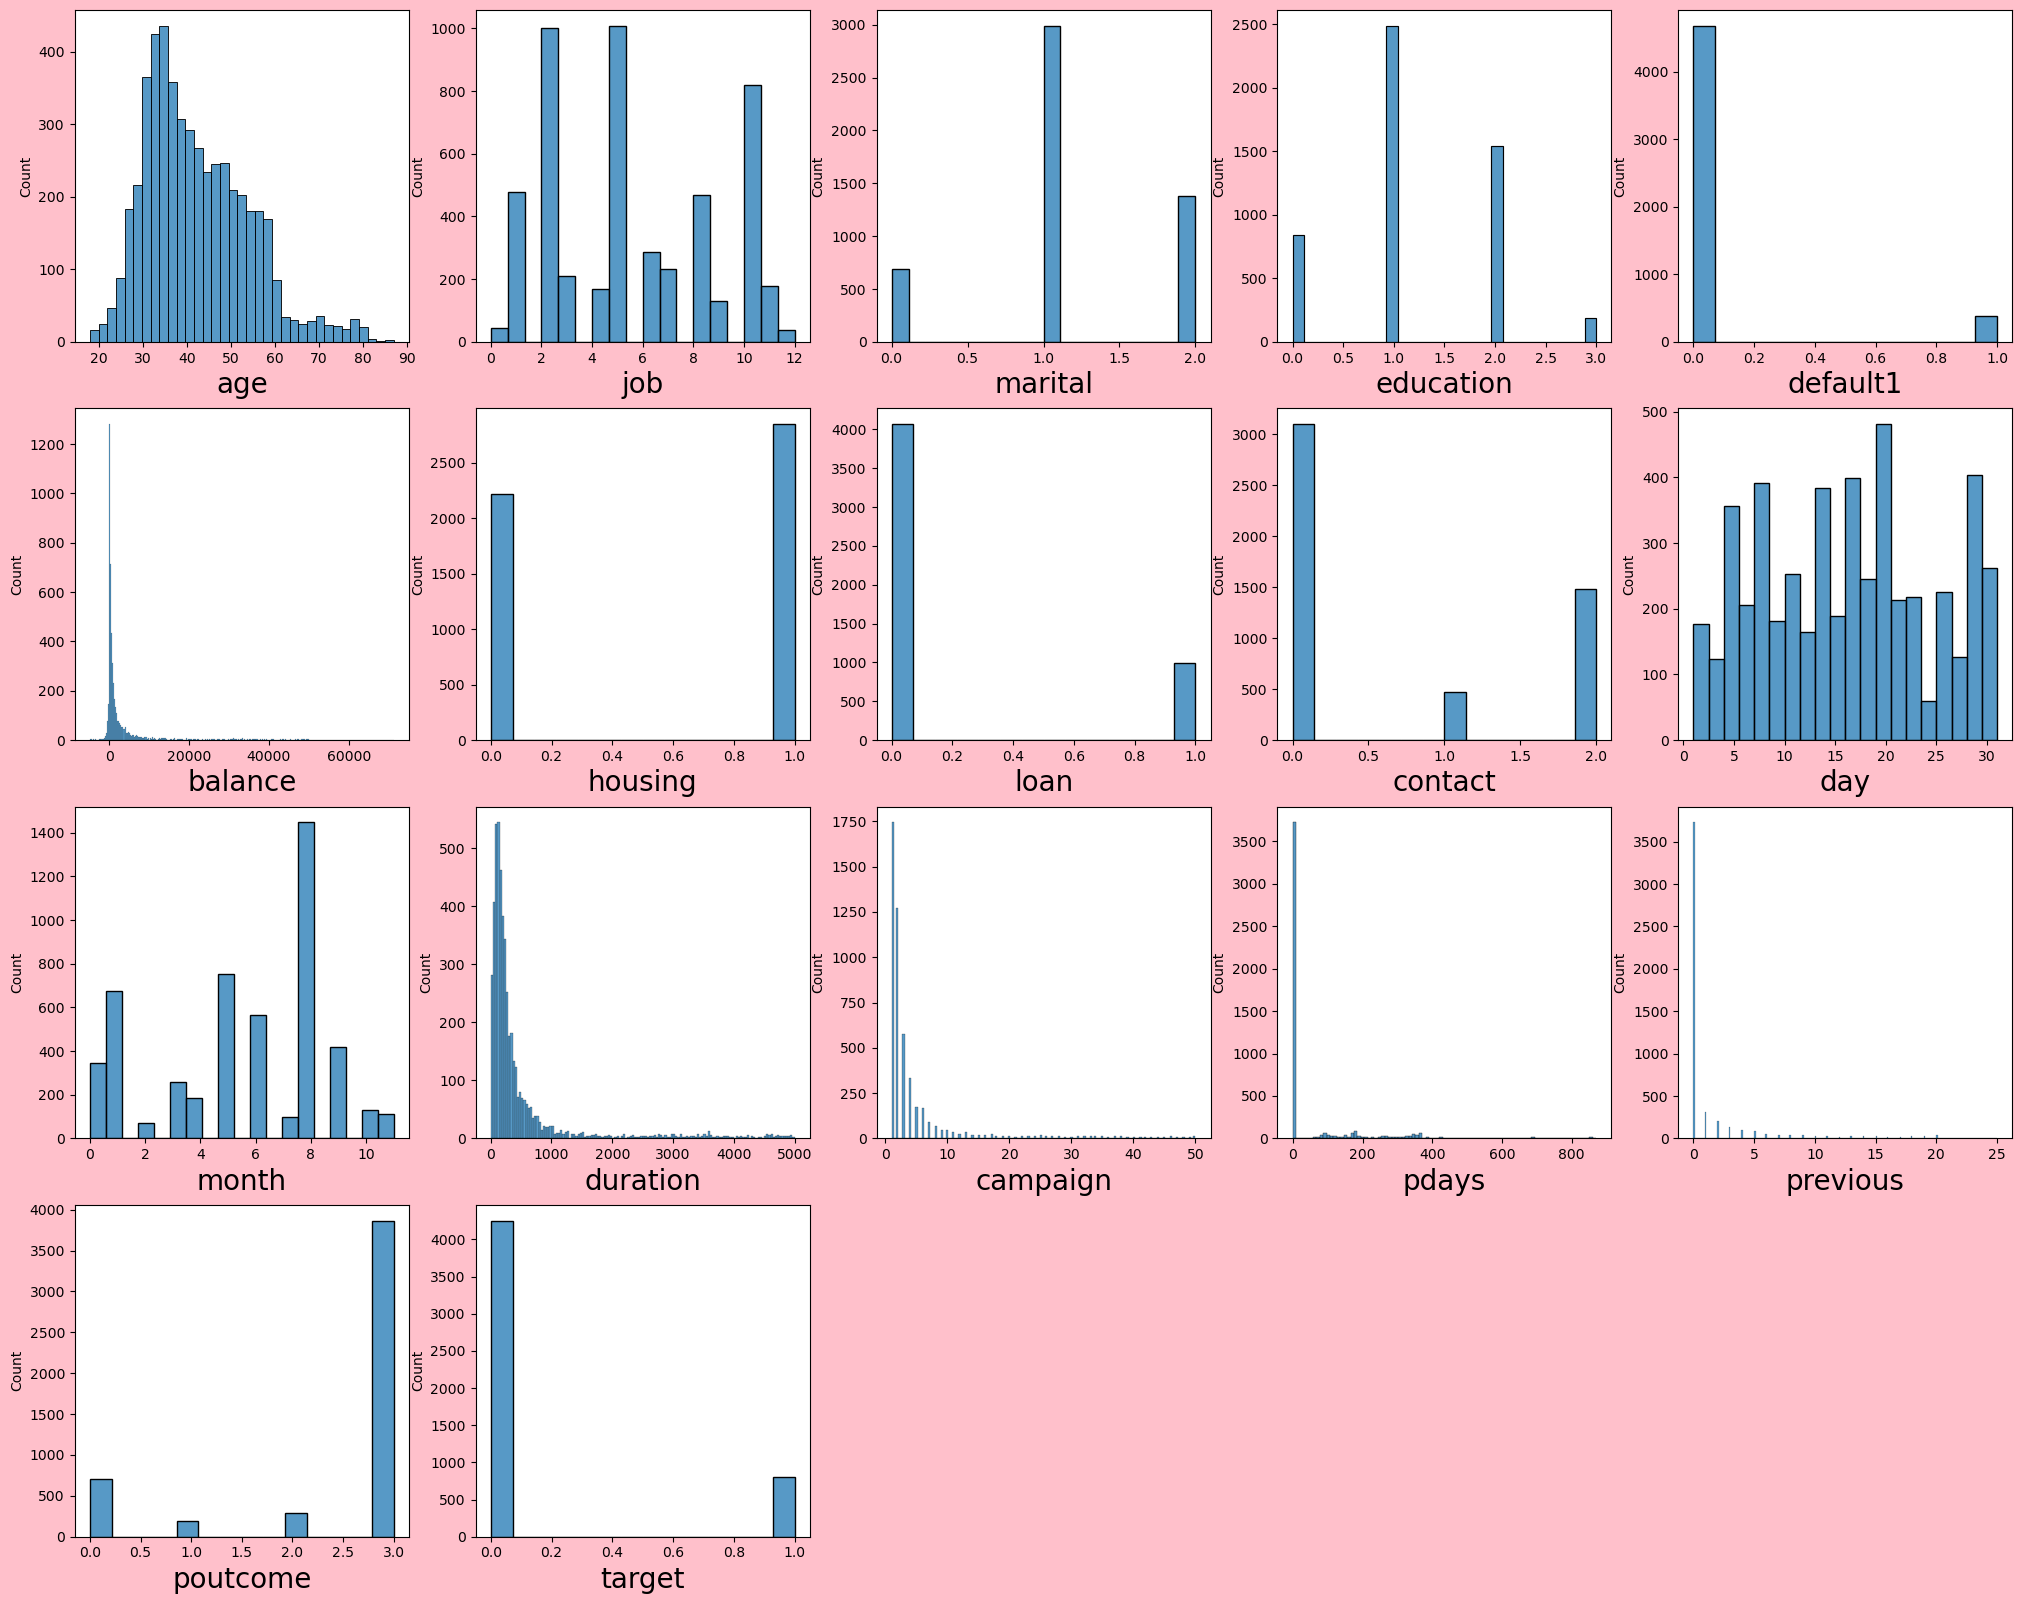

In [ ]:
plt.figure(figsize=(25,25), facecolor='pink')
plotnumber = 1

for column in df:
    if plotnumber<=21:
        ax = plt.subplot(5,5,plotnumber)
        sns.histplot(df[column])
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.show()

<Axes: xlabel='poutcome', ylabel='Density'>

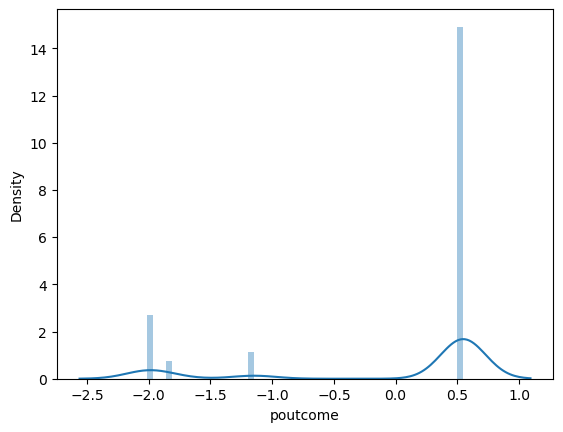

In [ ]:
collist = ['poutcome']
df[collist]=power_transform(df[collist],method='yeo-johnson')
df[collist]
df.skew()
sns.distplot(df['poutcome'])

In [ ]:
# Data Preprocessing
x=df.drop("target",axis=1)
y=df["target"]
x.columns
x.head(10)
y.head(10)
x.shape
y.shape
y.value_counts()
SM = SMOTE()
x, y = SM.fit_resample(x,y)
y.value_counts()

target
0    4253
1    4253
Name: count, dtype: int64

In [ ]:
# Scaling data using Standard Scaler
scaler = StandardScaler()
x = pd.DataFrame(scaler.fit_transform(x), columns = x.columns)
x.head()
x
var_threshold = VarianceThreshold(threshold=0)
var_threshold.fit(x)

var_threshold.get_support()
x.columns[var_threshold.get_support()]

# taking  out  all the  constant  columns 
cons_columns = [column for column in x.columns
               if column not in x.columns[var_threshold.get_support()]]
print(len(cons_columns))

0


In [ ]:
# SelectKBest method
best_fit = SelectKBest(score_func = f_classif, k ='all')
fit = best_fit.fit(x,y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(x.columns)
fit = best_fit.fit(x,y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(x.columns)
dfcolumns.head()
featureScores = pd.concat([dfcolumns,dfscores],axis = 1)
featureScores.columns = ['Feature', 'Score']
print(featureScores.nlargest(12,'Score'))

      Feature        Score
11   duration  1551.429922
14   previous  1001.846370
13      pdays   992.306802
6     housing   909.385600
5     balance   703.845906
15   poutcome   681.515099
12   campaign   564.376648
8     contact   555.956451
2     marital   323.891854
3   education   262.118419
4    default1   217.624244
0         age   116.880945


In [ ]:
# VIF(Variance Inflation factor)
vif = pd.DataFrame()
vif['VIF values'] = [variance_inflation_factor(x.values,i)for i in range(len(x.columns))]
vif['features'] = x.columns
vif


,VIF values,features
0,1.177616,age
1,1.032588,job
2,1.112149,marital
3,1.083874,education
4,1.399110,default1
5,2.151238,balance
6,1.124399,housing
7,1.129055,loan
8,1.216872,contact
9,1.010326,day


In [ ]:
# Creating Model
maxAccu = 0
maxRS = 0
for i in range(1,100):
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.30, random_state =i)
    DTC = DecisionTreeClassifier()
    DTC.fit(x_train,y_train)
    pred = DTC.predict(x_test)
    acc = accuracy_score(y_test,pred)
    if acc>maxAccu:
        maxAccu=acc
        maxRS=i
print('Best Accuracy is :- ', maxAccu, 'on Random State :- ',maxRS)

Best Accuracy is :-  0.8797021943573667 on Random State :-  36


### Split Data

In [ ]:
# Creating train-test Split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.15,random_state=maxRS)
x.shape
y.shape
x_train.shape,y_train.shape, x_test.shape,y_test.shape

((7230, 16), (7230,), (1276, 16), (1276,))

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def eval_metrics(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred)
    return rmse, mae, r2

### Train Models

  RMSE: 0.4461609139408411
  MAE: 0.19905956112852666
  R2: 0.20356609263191006
  Accuracy: 79.38


2025/08/29 09:58:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Accuracy Score:-  0.8009404388714734
Confusion Matrix :- 
  [[513 115]
 [139 509]]
Classification Report :- 
                precision    recall  f1-score   support

           0       0.79      0.82      0.80       628
           1       0.82      0.79      0.80       648

    accuracy                           0.80      1276
   macro avg       0.80      0.80      0.80      1276
weighted avg       0.80      0.80      0.80      1276

🏃 View run Logistic Regression at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/3/runs/cebf5b3de7284e4593aef6035d2e0af8
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/3


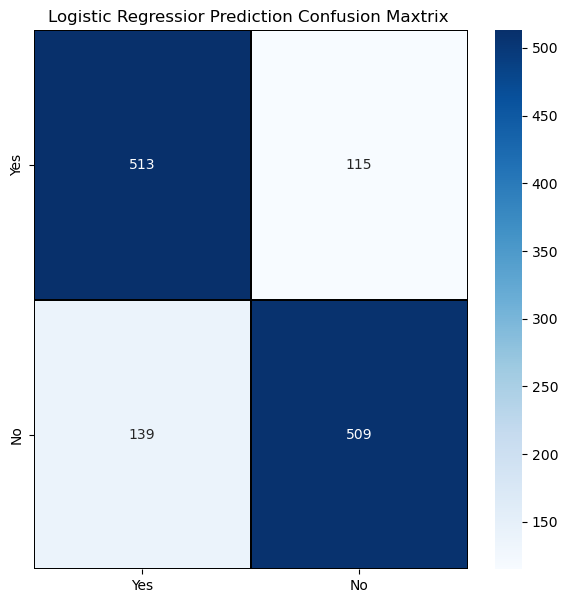

In [ ]:
# Logistic Regression
mlflow.end_run()
with mlflow.start_run(run_name='Logistic Regression', experiment_id=EXPERIMENT_ID):
    logreg = LogisticRegression()
    logreg.fit(x_train, y_train)

    predicted_qualities = logreg.predict(x_test)

    (rmse, mae, r2) = eval_metrics(y_test, predicted_qualities)
    accuracy = round(logreg.score(x, y) * 100, 2)
    print("  RMSE: %s" % rmse)
    print("  MAE: %s" % mae)
    print("  R2: %s" % r2)
    print("  Accuracy: %s" % accuracy)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.sklearn.log_model(logreg, "model")
    print('Accuracy Score:- ', accuracy_score(y_test,predicted_qualities))

    print('Confusion Matrix :- \n ', confusion_matrix(y_test,predicted_qualities))

    print('Classification Report :- \n ',classification_report(y_test,predicted_qualities))

    ### Here we are getting 85% accuracy using Logistic Regression.
    ## Confusion Matrix for Logistic Regression

    cm = confusion_matrix(y_test,predicted_qualities)
    x_axis_labels = ['Yes', 'No']
    y_axis_labels = ['Yes', 'No']
    f,ax = plt.subplots(figsize = (7,7))
    sns.heatmap(cm,annot = True, linewidths=.2,linecolor='black',fmt= '.0f',ax=ax, cmap = 'Blues',xticklabels=x_axis_labels,yticklabels=y_axis_labels)
    plt.title('Logistic Regressior Prediction Confusion Maxtrix ')
    mlflow.end_run()

  RMSE: 0.2785430072655778
  MAE: 0.07758620689655173
  R2: 0.6895789101203114
  Accuracy: 98.84


2025/08/29 09:59:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Random Forest Accuracy Score is:- 
 
   0.9224137931034483

 Confusion Matrix is :-
   [[561  67]
 [ 32 616]]

 Classification Report is 
                 precision    recall  f1-score   support

           0       0.95      0.89      0.92       628
           1       0.90      0.95      0.93       648

    accuracy                           0.92      1276
   macro avg       0.92      0.92      0.92      1276
weighted avg       0.92      0.92      0.92      1276

🏃 View run Random Forest Classifier at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/3/runs/b92da91ac5de4279b9a536567e80fcc6
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/3


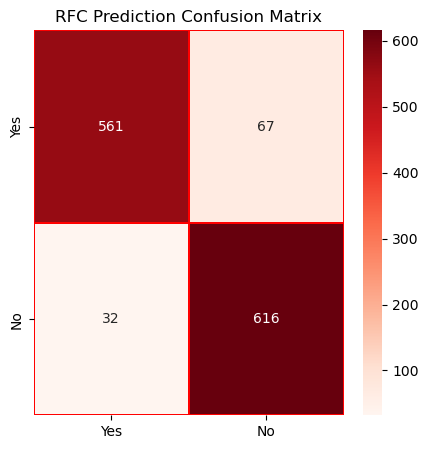

In [ ]:
# Classification Algorithms 
## Random Forest Classifier
with mlflow.start_run(run_name='Random Forest Classifier', experiment_id=EXPERIMENT_ID):
    random_forest = RandomForestClassifier()
    random_forest.fit(x_train, y_train)

    predicted_qualities = random_forest.predict(x_test)

    (rmse, mae, r2) = eval_metrics(y_test, predicted_qualities)
    accuracy = round(random_forest.score(x, y) * 100, 2)
    print("  RMSE: %s" % rmse)
    print("  MAE: %s" % mae)
    print("  R2: %s" % r2)
    print("  Accuracy: %s" % accuracy)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.sklearn.log_model(random_forest, "model")
    print('Random Forest Accuracy Score is:- \n \n  ',accuracy_score(y_test,predicted_qualities))
    print('\n Confusion Matrix is :-\n  ', confusion_matrix(y_test,predicted_qualities))
    print('\n Classification Report is \n  ', classification_report(y_test,predicted_qualities))
    ## Confusion Matrix for Random Forest Classifier.
    cm = confusion_matrix(y_test,predicted_qualities)
    x_axis_labels = ['Yes','No']
    y_axis_labels = ['Yes','No']
    f,ax = plt.subplots(figsize = (5,5))
    sns.heatmap(cm,annot=True,linewidths=.2,linecolor='red',fmt = '.0f',ax=ax,cmap='Reds',xticklabels = x_axis_labels,yticklabels=y_axis_labels)
    plt.title ('RFC Prediction Confusion Matrix')
    mlflow.end_run()



  RMSE: 0.3462743942494921
  MAE: 0.11990595611285267
  R2: 0.5202583156404812
  Accuracy: 98.2


2025/08/29 09:59:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Decision Tree Classifier Accuracy Score is:- 
 
   0.8800940438871473

 Confusion Matrix is :-
   [[554  74]
 [ 79 569]]

 Classification Report is 
                 precision    recall  f1-score   support

           0       0.88      0.88      0.88       628
           1       0.88      0.88      0.88       648

    accuracy                           0.88      1276
   macro avg       0.88      0.88      0.88      1276
weighted avg       0.88      0.88      0.88      1276

🏃 View run Decision Tree at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/3/runs/2875ce7040ad4223861f80e59a2316a2
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/3


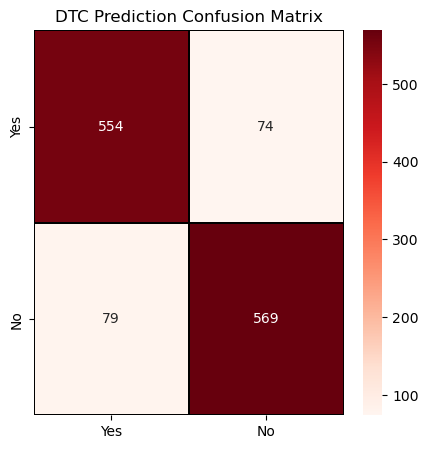

In [ ]:
# Decision Tree Classifier
with mlflow.start_run(run_name='Decision Tree', experiment_id=EXPERIMENT_ID):
    decision_tree = DecisionTreeClassifier()
    decision_tree.fit(x_train, y_train)

    predicted_qualities = decision_tree.predict(x_test)

    (rmse, mae, r2) = eval_metrics(y_test, predicted_qualities)
    accuracy = round(decision_tree.score(x, y) * 100, 2)
    print("  RMSE: %s" % rmse)
    print("  MAE: %s" % mae)
    print("  R2: %s" % r2)
    print("  Accuracy: %s" % accuracy)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.sklearn.log_model(decision_tree, "model")

    print('Decision Tree Classifier Accuracy Score is:- \n \n  ',accuracy_score(y_test,predicted_qualities))
    print('\n Confusion Matrix is :-\n  ', confusion_matrix(y_test,predicted_qualities))
    print('\n Classification Report is \n  ', classification_report(y_test,predicted_qualities))
    ## Confusion Matrix for Decision Tree Classifier.
    cm = confusion_matrix(y_test,predicted_qualities)
    x_axis_labels = ['Yes','No']
    y_axis_labels = ['Yes','No']
    f,ax = plt.subplots(figsize = (5,5))
    sns.heatmap(cm,annot=True,linewidths=.2,linecolor='black',fmt='.0f',ax=ax,cmap='Reds',xticklabels = x_axis_labels,yticklabels = y_axis_labels)
    plt.title('DTC Prediction Confusion Matrix')
    mlflow.end_run()

  RMSE: 0.4309717822734888
  MAE: 0.18573667711598746
  R2: 0.2568707242274122
  Accuracy: 80.23


2025/08/29 09:59:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Accuracy Score :-  0.8142633228840125
Confusion Matrix 
  [[502 126]
 [111 537]]
classification Report 
 :-                precision    recall  f1-score   support

           0       0.82      0.80      0.81       628
           1       0.81      0.83      0.82       648

    accuracy                           0.81      1276
   macro avg       0.81      0.81      0.81      1276
weighted avg       0.81      0.81      0.81      1276

🏃 View run SVM at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/3/runs/0a9333feca1a4f709f0fb6f4ea7e5b7b
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/3


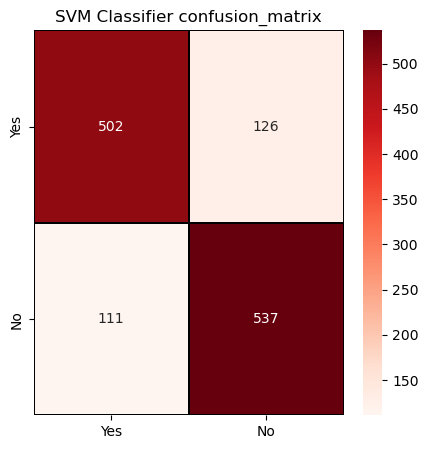

In [ ]:
# Support Vector Machine Classifier
with mlflow.start_run(run_name='SVM', experiment_id=EXPERIMENT_ID):
    linear_svc = SVC(kernel='linear',gamma='scale')
    linear_svc.fit(x_train, y_train)

    predicted_qualities = linear_svc.predict(x_test)

    (rmse, mae, r2) = eval_metrics(y_test, predicted_qualities)
    accuracy = round(linear_svc.score(x, y) * 100, 2)
    print("  RMSE: %s" % rmse)
    print("  MAE: %s" % mae)
    print("  R2: %s" % r2)
    print("  Accuracy: %s" % accuracy)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.sklearn.log_model(linear_svc, "model")
    print('Accuracy Score :- ',accuracy_score(y_test,predicted_qualities))
    print('Confusion Matrix \n ' ,confusion_matrix(y_test,predicted_qualities))
    print('classification Report \n :- ',classification_report(y_test,predicted_qualities))
    ## Confusion Matrix for Support Vector Machine Classifier.
    cm = confusion_matrix(y_test,predicted_qualities)
    x_axis_labels = ['Yes','No']
    y_axis_labels = ['Yes','No']
    f,ax = plt.subplots(figsize =(5,5))
    sns.heatmap(cm,annot=True,linewidths=.2,linecolor='black',fmt='.0f',ax=ax,cmap='Reds',xticklabels = x_axis_labels,yticklabels=y_axis_labels)
    plt.title('SVM Classifier confusion_matrix')
    mlflow.end_run()

  RMSE: 0.4245595172635511
  MAE: 0.18025078369905956
  R2: 0.2788196901785013
  Accuracy: 87.51


2025/08/29 09:59:16 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Accuracy Score:-  0.8197492163009404
Confusion Matrix:-  [[506 122]
 [108 540]]
Classifier Report:-                precision    recall  f1-score   support

           0       0.82      0.81      0.81       628
           1       0.82      0.83      0.82       648

    accuracy                           0.82      1276
   macro avg       0.82      0.82      0.82      1276
weighted avg       0.82      0.82      0.82      1276

🏃 View run KNN at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/3/runs/a50d2f1b5e3842cf8444e4882f9a79b7
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/3


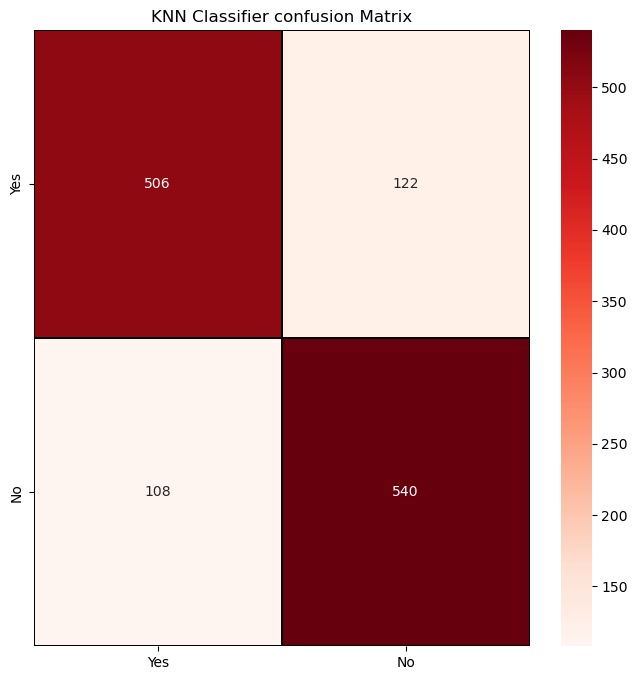

In [ ]:
# KNN Classifier
with mlflow.start_run(run_name='KNN', experiment_id=EXPERIMENT_ID):
    knn = KNeighborsClassifier()
    knn.fit(x_train, y_train)

    predicted_qualities = knn.predict(x_test)

    (rmse, mae, r2) = eval_metrics(y_test, predicted_qualities)
    accuracy = round(knn.score(x, y) * 100, 2)
    print("  RMSE: %s" % rmse)
    print("  MAE: %s" % mae)
    print("  R2: %s" % r2)
    print("  Accuracy: %s" % accuracy)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.sklearn.log_model(knn, "model")


    print('Accuracy Score:- ',accuracy_score(y_test,predicted_qualities))
    print('Confusion Matrix:- ',confusion_matrix(y_test,predicted_qualities))
    print('Classifier Report:- ', classification_report(y_test,predicted_qualities))
    ## Confusion Matrix for KNN Classifier.

    cm = confusion_matrix(y_test,predicted_qualities)
    x_axis_labels = ['Yes','No']
    y_axis_labels = ['Yes','No']
    f,ax = plt.subplots(figsize = (8,8))
    sns.heatmap(cm,annot=True,linewidths=.2,linecolor='black',fmt = '.0f',ax=ax,cmap='Reds',xticklabels = x_axis_labels,yticklabels = y_axis_labels)
    plt.title('KNN Classifier confusion Matrix')
    mlflow.end_run()

  RMSE: 0.3154834077479564
  MAE: 0.09952978056426333
  R2: 0.601783046315955
  Accuracy: 98.15


2025/08/29 09:59:58 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


GBC Accuracy Score is :  0.9004702194357367
GBC Confusion Matrix 
 [[554  74]
 [ 53 595]]
GBC Classification report 
               precision    recall  f1-score   support

           0       0.91      0.88      0.90       628
           1       0.89      0.92      0.90       648

    accuracy                           0.90      1276
   macro avg       0.90      0.90      0.90      1276
weighted avg       0.90      0.90      0.90      1276

🏃 View run Gradient Boosting Classifier at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/3/runs/fab9d5cb8bfc438bbd6565cb8081596f
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/3


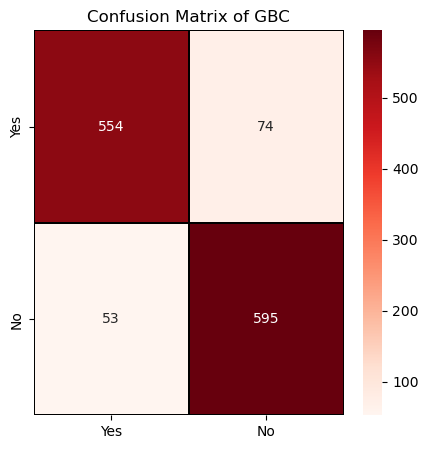

In [ ]:
# Gradient Boosting Classifier
with mlflow.start_run(run_name='Gradient Boosting Classifier', experiment_id=EXPERIMENT_ID):
    gradient_boosting = GradientBoostingClassifier(n_estimators=100,learning_rate=0.8,max_depth=4)
    gradient_boosting.fit(x_train, y_train)

    predicted_qualities = gradient_boosting.predict(x_test)

    (rmse, mae, r2) = eval_metrics(y_test, predicted_qualities)
    accuracy = round(gradient_boosting.score(x, y) * 100, 2)
    print("  RMSE: %s" % rmse)
    print("  MAE: %s" % mae)
    print("  R2: %s" % r2)
    print("  Accuracy: %s" % accuracy)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.sklearn.log_model(gradient_boosting, "model")
    print('GBC Accuracy Score is : ',accuracy_score(y_test,predicted_qualities))
    print('GBC Confusion Matrix \n',confusion_matrix(y_test,predicted_qualities))
    print('GBC Classification report \n',classification_report(y_test,predicted_qualities))
    ## Confusion Matrix for Gradient Boosting Classifier.
    cm = confusion_matrix(y_test,predicted_qualities)
    x_axis_labels = ['Yes','No']
    y_axis_labels = ['Yes','No']
    f,ax = plt.subplots(figsize = (5,5))
    sns.heatmap(cm,annot = True,linewidths=.2,linecolor='black',fmt='.0f',ax=ax,cmap='Reds',xticklabels = x_axis_labels,yticklabels = y_axis_labels)
    plt.title('Confusion Matrix of GBC')
    mlflow.end_run()

  RMSE: 0.27429019252949666
  MAE: 0.07523510971786834
  R2: 0.6989856098136353
  Accuracy: 98.73


2025/08/29 10:00:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


The Accuracy of XGBC is:  0.9247648902821317
Confusion Matrix of XGBC :- 
  [[571  57]
 [ 39 609]]
classification report of XGBC:- 
                precision    recall  f1-score   support

           0       0.94      0.91      0.92       628
           1       0.91      0.94      0.93       648

    accuracy                           0.92      1276
   macro avg       0.93      0.92      0.92      1276
weighted avg       0.93      0.92      0.92      1276

🏃 View run XGB Classifier at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/3/runs/e837cf9db325423ab53cf4e558a87743
🧪 View experiment at: http://mlflow.mlflow.svc.cluster.local:5000/#/experiments/3


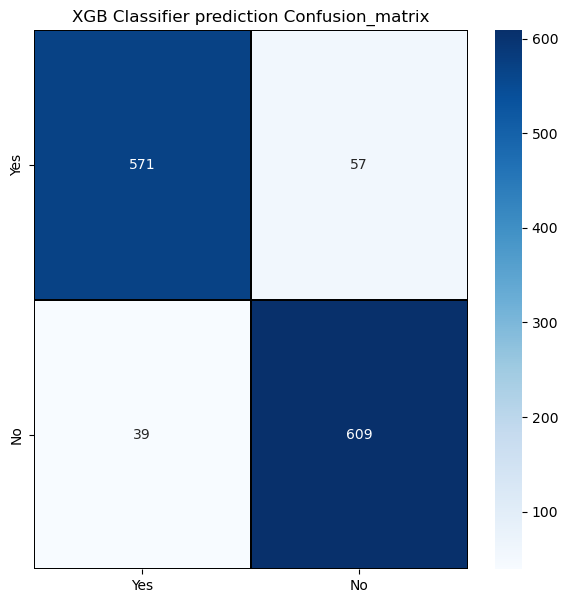

In [ ]:
# XGB Classifier
with mlflow.start_run(run_name='XGB Classifier', experiment_id=EXPERIMENT_ID):
    xgbc = XGBClassifier()
    xgbc.fit(x_train, y_train)

    predicted_qualities = xgbc.predict(x_test)

    (rmse, mae, r2) = eval_metrics(y_test, predicted_qualities)
    accuracy = round(xgbc.score(x, y) * 100, 2)
    print("  RMSE: %s" % rmse)
    print("  MAE: %s" % mae)
    print("  R2: %s" % r2)
    print("  Accuracy: %s" % accuracy)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("accuracy", accuracy)
    mlflow.xgboost.log_model(xgbc, 'model')

    print('The Accuracy of XGBC is: ',accuracy_score(y_test,predicted_qualities))
    print('Confusion Matrix of XGBC :- \n ', confusion_matrix(y_test,predicted_qualities))
    print('classification report of XGBC:- \n ', classification_report(y_test,predicted_qualities))
    ## Confusion Matrix for XGB Classifier.
    cm = confusion_matrix(y_test,predicted_qualities)
    x_axis_labels = ["Yes","No"]
    y_axis_labels = ["Yes","No"]

    f , ax = plt.subplots(figsize=(7,7))
    sns.heatmap(cm, annot = True,linewidths=.2, linecolor="black", fmt = ".0f", ax=ax, cmap="Blues", 
    xticklabels=x_axis_labels,
    yticklabels=y_axis_labels)
    plt.title("XGB Classifier prediction Confusion_matrix")
    mlflow.end_run()

In [ ]:
# Cross Validation Score for all the model
#    CV Score for Logistic Regrassion 
print('CV Score for logistic Regression :- ',cross_val_score(logreg,x,y,cv=5).mean())

#    CV Score for Random Forest Classifier

print('CV Score for Random Forest Classifier: ',cross_val_score(random_forest,x,y,cv=5).mean())

#    CV Score for Decision tree Classifier

print('CV score for Decision Tree Classifier',cross_val_score(decision_tree,x,y,cv=5).mean())


#    CV Score for support vector Classifire

print('CV Score for Support Vector Classifier ',cross_val_score(linear_svc,x,y,cv=5).mean())

#  CV Score for KNN classifier

print('CV Score for KNN Classifier',cross_val_score(knn,x,y,cv=5).mean())

#    CV Score for Gradian boosting Classifier

print('CV Score for Gradian Boosting Classifier',cross_val_score(gradient_boosting,x,y,cv=5).mean())

#   CV score for XGB Classifier

print('CV Score for XGB Classifier',cross_val_score(xgbc,x,y,cv=5).mean())

CV Score for logistic Regression :-  0.8016852601393664
CV Score for Random Forest Classifier:  0.9042077273961331
CV score for Decision Tree Classifier 0.8663492339820843
CV Score for Support Vector Classifier  0.8040355745669755
CV Score for KNN Classifier 0.8333166154422192
CV Score for Gradian Boosting Classifier 0.8920998292978968
CV Score for XGB Classifier 0.9051509756823766


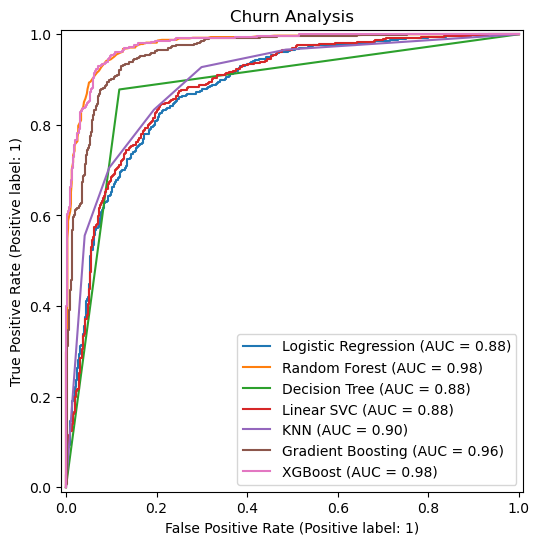

In [ ]:
### From the observation of accuracy and cross validation score and their difference we can predict that Random Forest Classifier is the best model.
# disp = plot_roc_curve(logreg,x_test,y_test)
# plot_roc_curve(random_forest,x_test,y_test,ax=disp.ax_)
# plot_roc_curve(decision_tree,x_test,y_test,ax=disp.ax_)
# plot_roc_curve(linear_svc,x_test,y_test,ax=disp.ax_)
# plot_roc_curve(knn,x_test,y_test,ax=disp.ax_)
# plot_roc_curve(gradient_boosting,x_test,y_test,ax=disp.ax_)
# plot_roc_curve(xgbc,x_test,y_test,ax=disp.ax_)

# plt.title('Churn Analysis')
# plt.legend(prop={'size' : 10},loc = 'lower right')
# plt.show()

fig, ax = plt.subplots(figsize=(8, 6))

# Plot ROC curve for each model
RocCurveDisplay.from_estimator(logreg, x_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(random_forest, x_test, y_test, ax=ax, name="Random Forest")
RocCurveDisplay.from_estimator(decision_tree, x_test, y_test, ax=ax, name="Decision Tree")
RocCurveDisplay.from_estimator(linear_svc, x_test, y_test, ax=ax, name="Linear SVC")
RocCurveDisplay.from_estimator(knn, x_test, y_test, ax=ax, name="KNN")
RocCurveDisplay.from_estimator(gradient_boosting, x_test, y_test, ax=ax, name="Gradient Boosting")
RocCurveDisplay.from_estimator(xgbc, x_test, y_test, ax=ax, name="XGBoost")

# Customize plot
plt.title("Churn Analysis")
plt.legend(prop={'size': 10}, loc="lower right")
plt.show()

In [ ]:
# Hyper Perametertuning for best model using GridsearchCV
# The XGB Classifier with GridsearchCV
params = {
    
    'n_estimators' : [100,200,500],
    'learning_rate' : [0.01,0.05,0.01],
    'booster': ['gbtree', 'gblinear'],
    'reg_alpha' : [0,0.5,1],
    'reg_lambda': [0.5,1,5],
    'base_score': [0.2,0.5,1]
}
CV_XGBC = GridSearchCV(XGBClassifier(n_jobs=-1),params,n_jobs=-1,cv = KFold(n_splits=3),scoring='roc_auc')
CV_XGBC.fit(x_train,y_train)
CV_XGBC.best_params_ 
CV_XGBC.best_estimator_
bank = XGBClassifier(base_score=0.2,booster='gbtree',learning_rate=0.1,n_estimators = 500, reg_alpha=0.5,reg_lambda=1)
bank.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,0.2
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Accuracy Score 0.932601880877743

  confusion matrix  
 [[572  56]
 [ 30 618]]

  Classification_matrix  
               precision    recall  f1-score   support

           0       0.95      0.91      0.93       628
           1       0.92      0.95      0.93       648

    accuracy                           0.93      1276
   macro avg       0.93      0.93      0.93      1276
weighted avg       0.93      0.93      0.93      1276



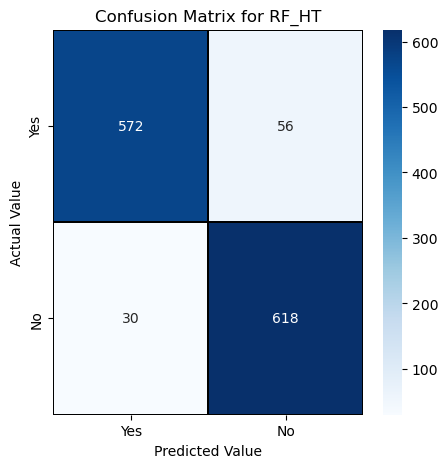

In [ ]:
# Here the final model gives 90% accuracy after tuning.
pred=bank.predict(x_test)
print('Accuracy Score',accuracy_score(y_test,pred))
print('\n  confusion matrix  \n',confusion_matrix(y_test,pred))
print('\n  Classification_matrix  \n',classification_report(y_test,pred))

cm = confusion_matrix(y_test,pred)
x_axis_labels = ['Yes','No']
y_axis_labels = ['Yes','No']
f,ax = plt.subplots(figsize = (5,5))
sns.heatmap(cm,annot=True,linewidths=0.2,linecolor='black',fmt = '.0f',ax=ax,cmap='Blues',xticklabels=x_axis_labels,yticklabels=y_axis_labels)
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.title('Confusion Matrix for RF_HT')
plt.show()

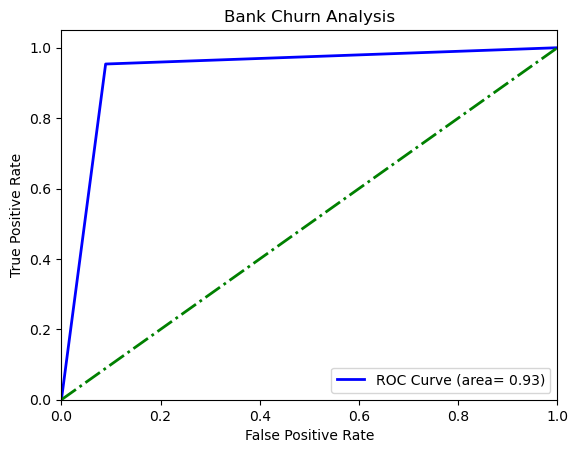

In [ ]:
# ROC-AUC Curve
fpr,tpr,threshold = roc_curve(y_test,pred)
auc = roc_auc_score(y_test,pred)
plt.figure()
plt.plot(fpr,tpr,color="blue",lw=2,label="ROC Curve (area= %0.2f)" % auc)
plt.plot([0,1],[0,1],color="green",lw=2,linestyle="dashdot")
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Bank Churn Analysis")
plt.legend(loc="lower right")
plt.show()

# This is the AUC-ROC curve for the models which is plotted False positive rate against True positive rate. So the best model has the area under curve as 0.90.

### Choose Best Model

In [ ]:
from mlflow import pyfunc
best_run_df = mlflow.search_runs(experiment_ids=[EXPERIMENT_ID], order_by=['metrics.accuracy DESC'], max_results=1)
best_run = mlflow.get_run(best_run_df.at[0, 'run_id'])
best_model_uri = f"{best_run.info.artifact_uri}/model/model.pkl"
is_xgbc = best_run.info.run_name == "XGB Classifier"
# best_model = pyfunc.load_model(best_model_uri)

print("Best run info:")
print(f"Run id: {best_run.info.run_id}")
print("Run Accuracy:  = {:.4f}\n".format(best_run.data.metrics['accuracy']))
print(f"Run model URI: {best_model_uri}")

Best run info:
Run id: b92da91ac5de4279b9a536567e80fcc6
Run Accuracy:  = 98.8400

Run model URI: s3://mlflow.apps-rag-cluster02/3/b92da91ac5de4279b9a536567e80fcc6/artifacts/model/model.pkl


### Register Model

In [ ]:
# Create a client
client = MlflowClient()

# Define the registered model name (choose a unique name in your workspace)
model_name = "investment_banking"

# Register the model from the artifact URI
model_version = mlflow.register_model(
    model_uri=best_model_uri,
    name=model_name
)
client.set_model_version_tag(
    name=model_name,
    version=model_version.version,
    key="staging",
    value="true"   # or "yes", or "active" depending on your convention
)

print(f"Model {model_name} v{model_version.version} registered and tagged with staging.")

Registered model 'investment_banking' already exists. Creating a new version of this model...
2025/09/01 05:29:05 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: investment_banking, version 2


Model investment_banking v2 registered and tagged with staging.


Created version '2' of model 'investment_banking'.


### Deploy Model

In [ ]:
import subprocess

api_version = 'serving.kserve.io/v1beta1'
model_name = 'bank-demo-1'
model_namespace = os.environ['NOTEBOOK_NAMESPACE']

inference_service = '''
apiVersion: "{}"
kind: "InferenceService"
metadata:
  name: {}
  namespace: {}
spec:
  predictor:
    serviceAccountName: kserve-local-s3
    {}:
      protocolVersion: "v2"
      storageUri: "{}"
'''.format(api_version, model_name, model_namespace, "sklearn" if not is_xgbc else "xgboost", best_model_uri)

subprocess.run('cat << EOF | kubectl apply -f -' + inference_service + 'EOF', shell=True)

inferenceservice.serving.kserve.io/bank-demo-1 created


CompletedProcess(args='cat << EOF | kubectl apply -f -\napiVersion: "serving.kserve.io/v1beta1"\nkind: "InferenceService"\nmetadata:\n  name: bank-demo-1\n  namespace: project-user-akansha-sajimon\nspec:\n  predictor:\n    serviceAccountName: kserve-local-s3\n    sklearn:\n      protocolVersion: "v2"\n      storageUri: "s3://mlflow.apps-rag-cluster02/3/b92da91ac5de4279b9a536567e80fcc6/artifacts/model/model.pkl"\nEOF', returncode=0)

### Inferencing

In [ ]:
import os
import requests

DOMAIN_NAME = "svc.cluster.local" # change this to your domain for external access 
NAMESPACE = os.environ['NOTEBOOK_NAMESPACE']
DEPLOYMENT_NAME = model_name
MODEL_NAME = model_name
if DOMAIN_NAME == "svc.cluster.local":
    PROTO = "http"
    SVC = f'{DEPLOYMENT_NAME}.{NAMESPACE}.{DOMAIN_NAME}'
    VERIFY = False
else:
    PROTO = "https"
    SVC = f'{DEPLOYMENT_NAME}.{NAMESPACE}.serving.{DOMAIN_NAME}'
    VERIFY = os.environ['EZUA_DOMAIN_CA_CERT_PATH']
URL = f"{PROTO}://{SVC}/v2/models/{MODEL_NAME}/infer"

print(URL)

http://bank-demo-1.project-user-akansha-sajimon.svc.cluster.local/v2/models/bank-demo-1/infer


In [ ]:
names=['age','job','marital','education','default1','balance','housing','loan','contact',
       'day','month','duration','campaign','pdays','previous','poutcome','target']

input_data = [
    [30,'unemployed','married','primary','no',1787,'no','no','cellular',19,'oct',79,1,-1,0,'unknown','no'],
    [36,'self-employed','married','tertiary','no',307,'yes','no','cellular',14,'may',341,1,330,2,'other','no']
]

Declined = {'age':30,'job':'unemployed','marital':'married','education':'primary','default1':'no','balance':1787,'housing':'no','loan':'no','contact':'cellular',
       'day':19,'month':'oct','duration':79,'campaign':1,'pdays':-1,'previous':0,'poutcome':'unknown'} #,'target':'no'}

Approved={'age':20,'job':'student','marital':'single','education':'secondary','default1':'no','balance':502,'housing':'no','loan':'no','contact':'cellular',
       'day':30,'month':'apr','duration':261,'campaign':1,'pdays':1,'previous':0,'poutcome':'unknown'} #,'target':'yes'}

enc = LabelEncoder()
for key, value in Declined.items():
    if isinstance(value, str):
        Declined[key] = 0.5 ## TODO

for key, value in Approved.items():
    if isinstance(value, str):
        Approved[key] = 0.5 ## TODO

inputs = {
  "inputs": [
    { 
      "name": "ndarray",
      "shape": [2,16], # 17],
      "datatype": "FP32",
      "data": [
        list(Approved.values()),
        list(Declined.values())  
      ]
    }
  ],
    "outputs": [
        {
            "name": "predict"
        },
        {
            "name": "predict_proba"
        }
    ]
}

headers = {
    'Accept': 'application/json',
    'Content-Type': 'application/json',
     "Authorization": f"Bearer {os.environ['AUTH_TOKEN']}"
}
json_request = json.dumps(inputs)
print(json_request)
response = requests.post(URL, headers=headers, data=json_request, verify=False)
print(response.reason)
outputs = response.json()["outputs"]
print(outputs)

# response = requests.post(URL, json=inputs, headers=headers, verify=False)

# print(response.reason)

# output = response.json()['outputs']

# print("eligible for investment banking\n")
# for item, out in zip(input_data, output):
#     input_dict = dict(zip(names,item))
#     print(f"Input Data: {input_dict} \n\ntarget customers{out}\n")


{"inputs": [{"name": "ndarray", "shape": [2, 16], "datatype": "FP32", "data": [[20, 0.5, 0.5, 0.5, 0.5, 502, 0.5, 0.5, 0.5, 30, 0.5, 261, 1, 1, 0, 0.5], [30, 0.5, 0.5, 0.5, 0.5, 1787, 0.5, 0.5, 0.5, 19, 0.5, 79, 1, -1, 0, 0.5]]}], "outputs": [{"name": "predict"}, {"name": "predict_proba"}]}
OK
[{'name': 'predict', 'shape': [2, 1], 'datatype': 'INT64', 'parameters': {'content_type': 'np'}, 'data': [1, 1]}, {'name': 'predict_proba', 'shape': [2, 2], 'datatype': 'FP64', 'parameters': {'content_type': 'np'}, 'data': [0.49, 0.51, 0.46, 0.54]}]


In [ ]:
label_map = {0: "no", 1: "yes"}
pred_classes = outputs[0]["data"]
pred_probs = outputs[1]["data"]

for i, (pred, probs) in enumerate(zip(pred_classes, zip(pred_probs[::2], pred_probs[1::2]))):
    input_dict = dict(zip(names, input_data[i]))
    human_label = label_map[pred]
    prob_yes = probs[1] * 100  # probability of class 1
    prob_no = probs[0] * 100   # probability of class 0
    
    print(f"Customer {i+1}:")
    print(f"  Input Data: {input_dict}")
    print(f"  Prediction: {human_label.upper()} (yes={prob_yes:.2f}%, no={prob_no:.2f}%)\n")

Customer 1:
  Input Data: {'age': 30, 'job': 'unemployed', 'marital': 'married', 'education': 'primary', 'default1': 'no', 'balance': 1787, 'housing': 'no', 'loan': 'no', 'contact': 'cellular', 'day': 19, 'month': 'oct', 'duration': 79, 'campaign': 1, 'pdays': -1, 'previous': 0, 'poutcome': 'unknown', 'target': 'no'}
  Prediction: YES (yes=51.00%, no=49.00%)

Customer 2:
  Input Data: {'age': 36, 'job': 'self-employed', 'marital': 'married', 'education': 'tertiary', 'default1': 'no', 'balance': 307, 'housing': 'yes', 'loan': 'no', 'contact': 'cellular', 'day': 14, 'month': 'may', 'duration': 341, 'campaign': 1, 'pdays': 330, 'previous': 2, 'poutcome': 'other', 'target': 'no'}
  Prediction: YES (yes=54.00%, no=46.00%)

